# Lab 01 — 網路流量特徵工程與 Baseline

Lab 00 把 `detector.py` 的 `rolling_zscore()` 接上即時流量，比較了三種視窗長度。這一節我們改用有 Ground Truth Events 標記的資料，以便於驗證結果。

本實驗使用一份 30 天的歷史資料：5 個 Port 的 SNMP 介面計數，取樣間隔 300 秒（共 43,200 列），內含 10 個事件（18 個獨立的事件×Port 時窗）。

> **環境設定：** 所有分析都在 Notebook 內完成，讀取 `data/synthetic/` 路徑下的 CSV 檔。不需要啟動 Prometheus、node_exporter、Grafana 或 `detector.py`。若 Lab 00 的服務仍在執行，直接關閉即可。

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COURSE_ROOT = pathlib.Path.cwd()
while COURSE_ROOT != COURSE_ROOT.parent and not (COURSE_ROOT / "environments").is_dir():
    COURSE_ROOT = COURSE_ROOT.parent
OUT = COURSE_ROOT / "outputs" / "workshop"
OUT.mkdir(parents=True, exist_ok=True)

# serif house style, matching the diagrams and the printed course notes
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Georgia", "Times New Roman", "DejaVu Serif"],
    "figure.dpi": 110, "axes.titlesize": 11, "axes.titlelocation": "left",
    "axes.labelsize": 9, "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

print(f"pandas {pd.__version__}   numpy {np.__version__}")
print(f"course root  {COURSE_ROOT}")

pandas 3.0.3   numpy 2.4.6
course root  /Users/kevin/Library/CloudStorage/GoogleDrive-kevin880987@gmail.com/我的雲端硬碟/workshop/workbench/project/202608-aia-network-monitoring-aiops/aiops-anomaly-zero-to-hero


In [2]:
# ------------------------------------------------------------------------------
# 共用常數。
# ------------------------------------------------------------------------------
from dataclasses import dataclass

DATA = COURSE_ROOT / "data" / "synthetic"
MAD_TO_SIGMA = 1.4826 # To convert the Median Absolute Deviation (MAD) to an estimate of the standard deviation (σ), you multiply the MAD by a scaling factor. For a normally distributed dataset, the conversion factor is approximately 1.4826 (σ ≈ 1.4826 × MAD). If you are using the Mean Absolute Deviation, the conversion factor for a normal distribution is approximately 1.253.

MAX_SCORE = 50.0

PALETTE = {"signal": "#3B7DD8", "baseline": "#E0752D", "score": "#7A5AC7",
           "alert": "#D6455D", "truth": "#FF9F1C", "peer": "#2E9E7B", "muted": "#9AA4B0"}

RAW_COLUMNS = ["INOCTETS", "OUTOCTETS", "INUCASTPKTS", "OUTUCASTPKTS",
               "INNUCASTPKTS", "OUTNUCASTPKTS", "INBROADCASTPKTS", "OUTBROADCASTPKTS",
               "INMULTICASTPKTS", "OUTMULTICASTPKTS", "INERRORS", "OUTERRORS",
               "INDISCARDS", "OUTDISCARDS", "INUNKNOWNPROTOS"]

## 1. Dataset

為了課程方便，`load_telemetry()` 讀到的每一列本身就是該取樣區間的總量，直接除以取樣間隔（Cadence）就是每秒速率，不需要對欄位做 `.diff()`。

### 數據剖面與特性

1. **尺度差異：** 5 個 Port 的流量級距跨越一個數量級，因此靜態的全域閾值（例如 $X\text{ MB/s}$）無法通用，Baseline 演算法必須先將尺度正規化。
2. **變異數塌陷（Degenerate Variance）：** 當欄位內大半數值都是 0，滾動離散度（標準差或 MAD）會塌陷至零，導致任何非零數值被放大成無限大的 Z-score。0 值比例過半的特徵，應改用固定閾值而非統計 Z-score。
3. **自我相關（Autocorrelation）與視窗下限：** 落後自相關強度決定了 Rolling Window 的長度下限。視窗若短於最強的週期長度，Baseline 會跟著正常的週期起伏一起變動，失去偵測效果。
4. **特徵共線性（Feature Collinearity）：** 高度相關的特徵（如 `traffic_bps` 與 `packets_pps`，Spearman $r \approx 1.0$）反映相同的訊號，同時採計無法提供額外資訊。相反地，弱相關的形狀特徵能提供獨立證據，這也是後續跨特徵取最大值（`score_max`）的理論依據。

先看一眼原始 CSV 長什麼樣子。下面這張圖畫的是完全沒處理過的 `INOCTETS`。

raw csv: 43,200 rows x 21 columns
            timestamp      port_id      port_role    INOCTETS   OUTOCTETS event_label
0 2026-02-01 00:00:00  port-id7429  server-uplink  2265462.07  4192099.47      normal
1 2026-02-01 00:05:00  port-id7429  server-uplink  2005792.42  3515720.85      normal
2 2026-02-01 00:10:00  port-id7429  server-uplink  2428590.58  3695842.09      normal
3 2026-02-01 00:15:00  port-id7429  server-uplink  2135617.90  3318714.69      normal
4 2026-02-01 00:20:00  port-id7429  server-uplink  2537236.96  3570158.14      normal


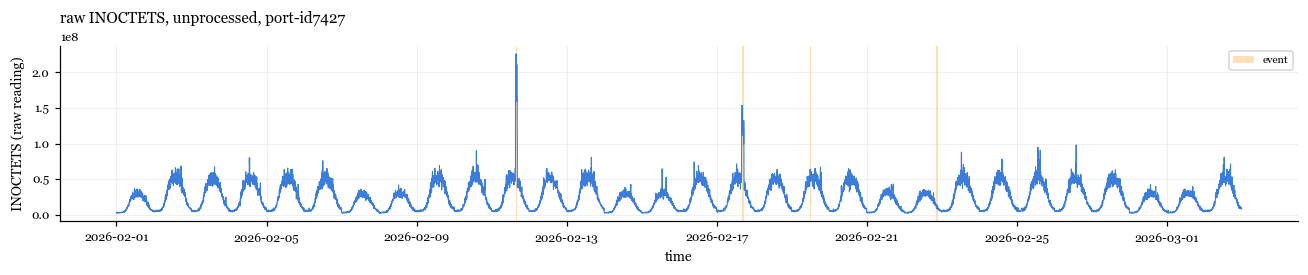

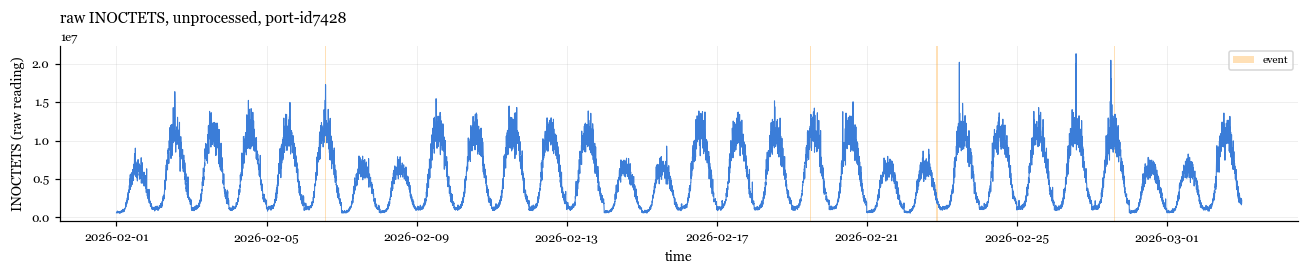

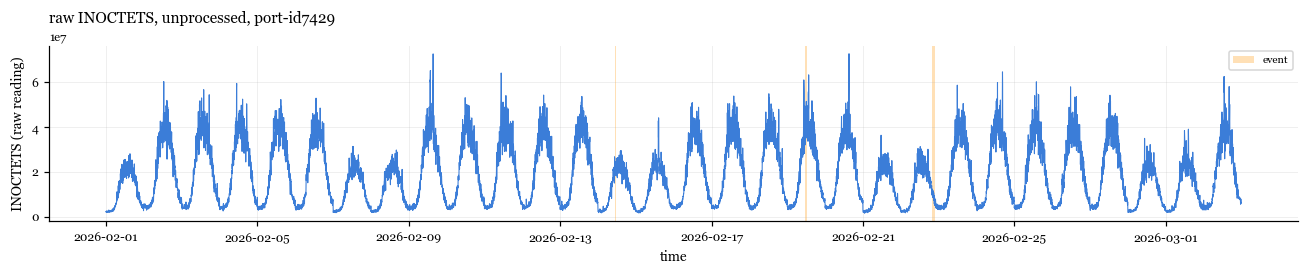

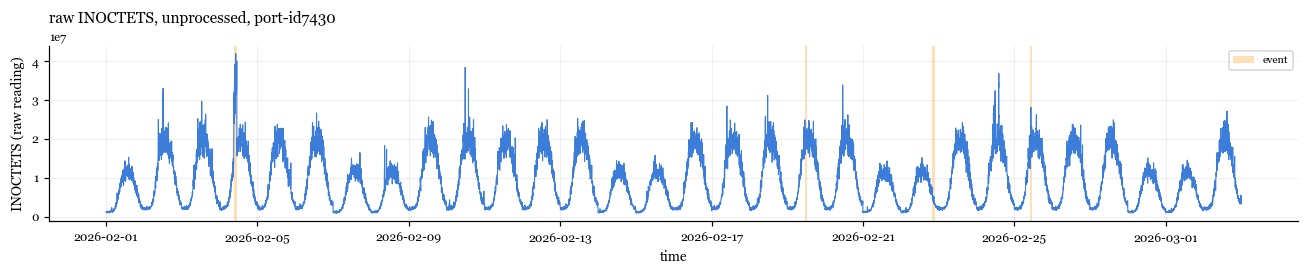

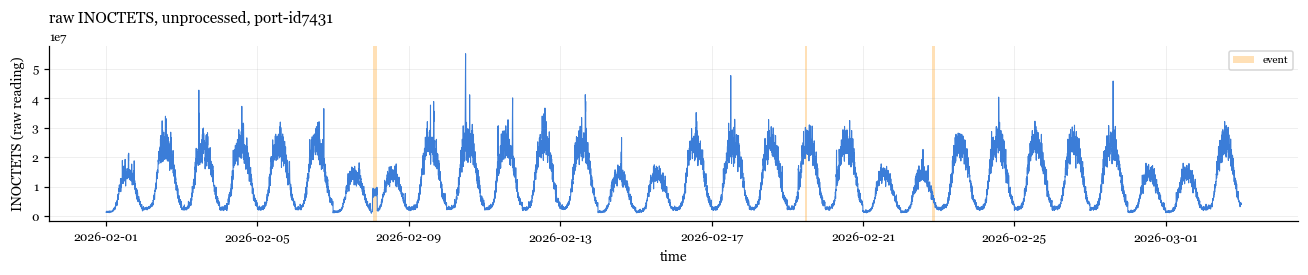

In [3]:
def shade_truth(ax, time, mask, color=None, alpha=0.32, legend="event"):
    """Shade contiguous True runs of a boolean mask as one legend entry."""
    color = PALETTE["truth"] if color is None else color
    values = np.asarray(pd.Series(mask).fillna(False), dtype=bool)
    idx = np.flatnonzero(values)
    if idx.size == 0:
        return
    brk = np.flatnonzero(np.diff(idx) > 1)
    starts = np.concatenate([[idx[0]], idx[brk + 1]])
    ends = np.concatenate([idx[brk], [idx[-1]]])
    time = pd.Series(time).reset_index(drop=True)
    for n, (a, b) in enumerate(zip(starts, ends)):
        ax.axvspan(time.iloc[a], time.iloc[b], color=color, alpha=alpha,
                   linewidth=0, zorder=0, label=legend if n == 0 else None)

raw_preview = pd.read_csv(DATA / "synthetic_rrd_metrics.csv", parse_dates=["timestamp"])
print(f"raw csv: {raw_preview.shape[0]:,} rows x {raw_preview.shape[1]} columns")
print(raw_preview[["timestamp", "port_id", "port_role", "INOCTETS", "OUTOCTETS", "event_label"]].head())


for port in sorted(raw_preview["port_id"].unique()):
    one_port = raw_preview[raw_preview["port_id"] == port].sort_values("timestamp")

    fig, ax = plt.subplots(figsize=(12, 2.6))
    ax.plot(one_port["timestamp"], one_port["INOCTETS"], color=PALETTE["signal"], lw=0.7)
    shade_truth(ax, one_port["timestamp"], one_port["event_label"] != "normal")
    ax.set_title(f"raw INOCTETS, unprocessed, {port}", loc="left", fontsize=10)
    ax.set_xlabel("time")
    ax.set_ylabel("INOCTETS (raw reading)")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    plt.show()

In [4]:
def infer_cadence(timestamps, group=None):
    """Median sampling interval in seconds, per series when grouped.

    Measured, not assumed: every rolling-window length used later (WINDOW,
    the CUSUM/EWMA windows, the confirmation delay math) is expressed in
    samples, and a wrong cadence would silently scale every one of those
    windows by the same wrong factor, with nothing in the output to signal it.
    """
    if group is None:
        deltas = timestamps.sort_values().diff().dt.total_seconds()  # gaps between consecutive samples
    else:
        f = pd.DataFrame({"ts": timestamps, "g": group}).sort_values(["g", "ts"])
        deltas = f.groupby("g", observed=True)["ts"].diff().dt.total_seconds()  # gaps within each group (port), not across groups
    deltas = deltas.dropna()
    deltas = deltas[deltas > 0]  # drop the first row of each group (NaN) and any non-positive artifact
    if deltas.empty:
        raise ValueError("cannot infer cadence: no positive timestamp differences")
    return float(deltas.median())  # median, not mean: robust to the rare missed/duplicated sample


@dataclass
class Contract:
    """What the loader read from the raw file, so a lab can print it."""
    cadence_s: float
    n_rows: int
    n_ports: int
    span: tuple

    def describe(self):
        lo, hi = self.span
        lines = [f"rows            {self.n_rows:,} across {self.n_ports} ports",
                 f"span            {lo}  ->  {hi}",
                 f"cadence         {self.cadence_s:.0f} s per sample "
                 f"({self.cadence_s / 60:.0f} min; {int(round(86400 / self.cadence_s))} samples/day)"]
        return "\n".join(lines)


def load_telemetry(csv_path=None, ports=None):
    """Load the course telemetry as per-second rates, one row per (port, timestamp).

    Each raw row already holds the total accumulated within the polling
    interval, so the rate is just the value divided by the cadence. This is
    the load step only: no derived feature (traffic_bps, ratios, ...) exists
    yet, that is `_add_derived_features()`, a separate step below.
    """
    csv_path = (DATA / "synthetic_rrd_metrics.csv") if csv_path is None else csv_path
    raw = pd.read_csv(csv_path, parse_dates=["timestamp"])
    if ports:
        raw = raw[raw["port_id"].isin(ports)]  # optionally restrict to a subset of ports, for a lighter-weight demo
    raw = raw.sort_values(["device_id", "port_id", "timestamp"]).reset_index(drop=True)  # ordering matters for every rolling computation downstream

    cadence = infer_cadence(raw["timestamp"], raw["port_id"])  # seconds per sample, drives WINDOW and every later time-based parameter

    out = pd.DataFrame({
        "timestamp": raw["timestamp"],
        "device_id": raw["device_id"].astype(str),
        "port_id": raw["port_id"].astype(str),
        "port_role": raw["port_role"].astype(str),
        "event_label": raw.get("event_label", pd.Series("normal", index=raw.index)).astype(str),  # ground-truth label, "normal" if the CSV carries none
        "event_id": raw.get("event_id", pd.Series(pd.NA, index=raw.index)).astype("string").fillna(""),
    })
    for col in RAW_COLUMNS:
        if col in raw.columns:
            out[col.lower() + "_ps"] = raw[col].astype(float) / cadence  # counter total for the interval -> per-second rate; the only unit conversion at this stage

    contract = Contract(cadence, len(out), int(out["port_id"].nunique()),
                        (out["timestamp"].min(), out["timestamp"].max()))
    return out, contract


raw_rates, contract = load_telemetry()
print(contract.describe())

CADENCE_S = contract.cadence_s
WINDOW = int(round(3600 / CADENCE_S))  # every baseline in this course is defined as "1 hour of history", expressed here in samples
print()
print(f"1h rolling window = {WINDOW} samples at {CADENCE_S:.0f}s cadence")

print()
print("dataset shape, loaded and rate-converted, not yet engineered:")
print(raw_rates.shape)

rows            43,200 across 5 ports
span            2026-02-01 00:00:00  ->  2026-03-02 23:55:00
cadence         300 s per sample (5 min; 288 samples/day)

1h rolling window = 12 samples at 300s cadence

dataset shape, loaded and rate-converted, not yet engineered:
(43200, 21)


### 特徵工程 (Feature Engineering) 與特徵萃取 (Feature Extraction)

上面的 `raw_rates` 只做了單位換算（計數換成每秒速率），還沒有任何一個衍生欄位。`_add_derived_features()` 在這裡把它變成 `telemetry`，包含 traffic_bps、封包比率等等。

In [5]:
def _add_derived_features(df):
    eps = 1e-9
    rx, tx = df["inoctets_ps"], df["outoctets_ps"]
    ucast = df["inucastpkts_ps"] + df["outucastpkts_ps"]
    nucast = df.get("innucastpkts_ps", 0) + df.get("outnucastpkts_ps", 0)
    bcast = df["inbroadcastpkts_ps"] + df["outbroadcastpkts_ps"]
    mcast = df["inmulticastpkts_ps"] + df["outmulticastpkts_ps"]
    errors = df["inerrors_ps"] + df["outerrors_ps"]
    discards = df["indiscards_ps"] + df["outdiscards_ps"]
    packets = ucast + nucast
    df["traffic_bps"] = rx + tx  # 總流量：進 + 出位元組速率
    df["packets_pps"] = packets  # 總封包速率：單播 + 非單播
    df["errors_pps"] = errors  # 錯誤封包速率：進 + 出
    df["discards_pps"] = discards  # 丟棄封包速率：進 + 出
    df["broadcast_pps"] = bcast  # 廣播封包速率：進 + 出
    df["multicast_pps"] = mcast  # 多播封包速率：進 + 出
    df["unknown_proto_pps"] = df.get("inunknownprotos_ps", 0.0)  # 未知協定封包速率
    df["error_rate"] = errors / (packets + eps)  # 錯誤率：錯誤封包佔總封包比例
    df["discard_rate"] = discards / (packets + eps)  # 丟棄率：丟棄封包佔總封包比例
    df["err_disc_rate"] = (errors + discards) / (packets + eps)  # 錯誤加丟棄率，合併成單一線路品質訊號
    df["tx_ratio"] = tx / (rx + tx + eps)  # 送出流量佔總流量比例，看流量方向偏哪邊
    df["avg_pkt_bytes"] = (rx + tx) / (packets + bcast + mcast + eps)  # 平均封包大小
    df["broadcast_ratio"] = bcast / (packets + bcast + mcast + eps)  # 廣播封包佔全部封包比例
    df["multicast_ratio"] = mcast / (packets + bcast + mcast + eps)  # 多播封包佔全部封包比例
    df["nonucast_ratio"] = (bcast + mcast) / (packets + bcast + mcast + eps)  # 廣播加多播佔全部封包比例
    return df


telemetry = _add_derived_features(raw_rates.copy())
print("engineered columns added on top of the loaded rates:")
print([c for c in telemetry.columns if c not in raw_rates.columns])

engineered columns added on top of the loaded rates:
['traffic_bps', 'packets_pps', 'errors_pps', 'discards_pps', 'broadcast_pps', 'multicast_pps', 'unknown_proto_pps', 'error_rate', 'discard_rate', 'err_disc_rate', 'tx_ratio', 'avg_pkt_bytes', 'broadcast_ratio', 'multicast_ratio', 'nonucast_ratio']


In [6]:
# 這是 _add_derived_features() 跑完之後的結果，不是原始 CSV。
ENGINEERED_CSV = OUT / "telemetry_engineered.csv"
telemetry.to_csv(ENGINEERED_CSV, index=False)
print(f"engineered frame -> {ENGINEERED_CSV}")
print(f"{telemetry.shape[0]:,} rows x {telemetry.shape[1]} cols, "
      f"{ENGINEERED_CSV.stat().st_size / 1e6:.1f} MB on disk")

engineered frame -> /Users/kevin/Library/CloudStorage/GoogleDrive-kevin880987@gmail.com/我的雲端硬碟/workshop/workbench/project/202608-aia-network-monitoring-aiops/aiops-anomaly-zero-to-hero/outputs/workshop/telemetry_engineered.csv
43,200 rows x 36 cols, 18.7 MB on disk


特徵工程之後，同樣 5 個 port 的 `traffic_bps` 長這樣，事件時窗也標了出來，跟上面的原始 `INOCTETS` 對照著看。

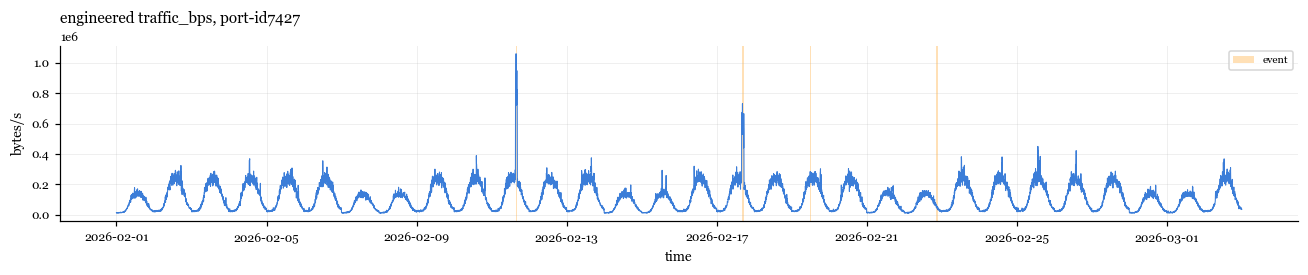

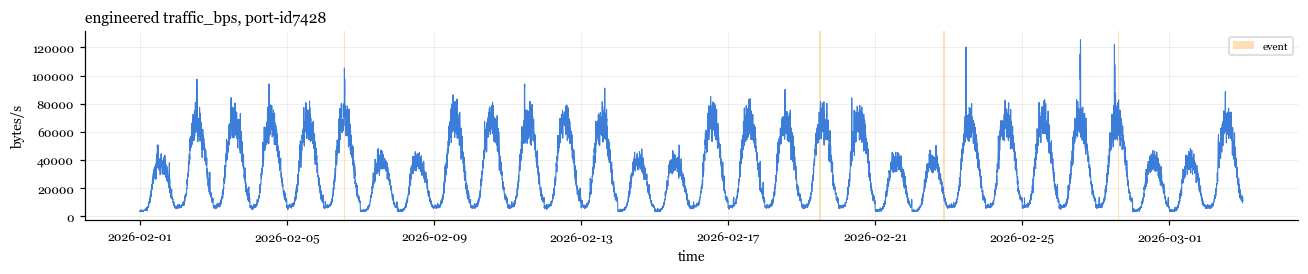

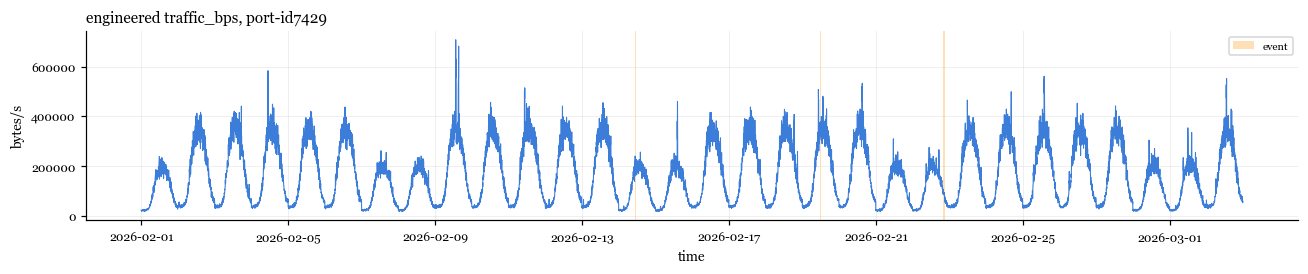

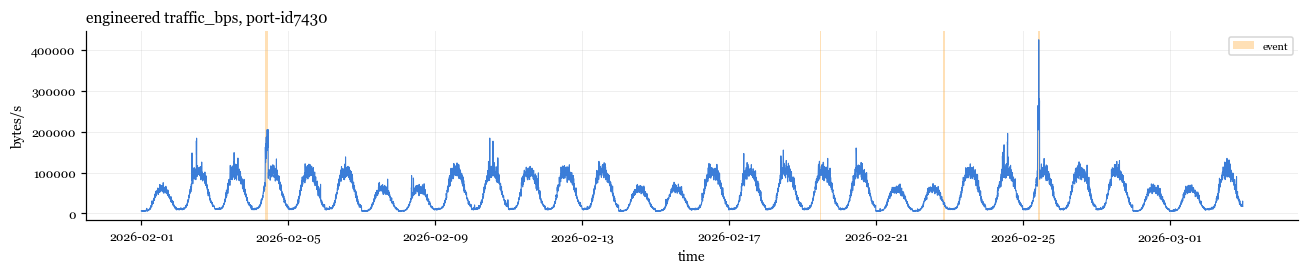

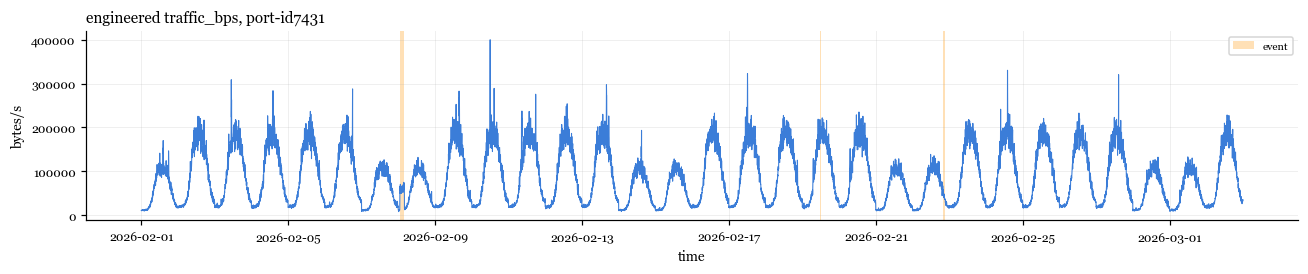

In [7]:
# Same 5 ports as the raw plot above, now on the engineered traffic_bps column.
# Comparing the two views directly is the point: engineering did not change
# what happened, only what the detector is able to measure.
for port in sorted(telemetry["port_id"].unique()):
    one_port = telemetry[telemetry["port_id"] == port].sort_values("timestamp")

    fig, ax = plt.subplots(figsize=(12, 2.6))
    ax.plot(one_port["timestamp"], one_port["traffic_bps"], color=PALETTE["signal"], lw=0.7)
    shade_truth(ax, one_port["timestamp"], one_port["event_label"] != "normal")
    ax.set_title(f"engineered traffic_bps, {port}", loc="left", fontsize=10)
    ax.set_xlabel("time")
    ax.set_ylabel("bytes/s")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    plt.show()

In [8]:
# 資料剖面。所有數字都從 telemetry 計算。
PROFILE_COLS = ["traffic_bps", "packets_pps", "avg_pkt_bytes", "broadcast_ratio",
                "multicast_ratio", "tx_ratio", "error_rate", "discard_rate",
                "errors_pps", "unknown_proto_pps", "err_disc_rate", "nonucast_ratio"]

inventory = (
    telemetry.groupby(["device_id", "port_id", "port_role"], observed=True)
    .agg(median_MBps=("traffic_bps", lambda s: s.median() / 1e6),
         p95_MBps=("traffic_bps", lambda s: s.quantile(0.95) / 1e6))
    .reset_index().sort_values("median_MBps")
)

zero_frac = (telemetry[PROFILE_COLS] == 0).mean()

# 整批資料的健康檢查。
steps = (telemetry.sort_values(["port_id", "timestamp"])
         .groupby("port_id", observed=True)["timestamp"].diff().dt.total_seconds().dropna())
labelled = telemetry["event_label"] != "normal"
print(f"shape        {telemetry.shape[0]:,} rows x {telemetry.shape[1]} cols;  "
      f"1h window {WINDOW} samples, 1d {int(round(86400 / CADENCE_S))}")
print(f"integrity    間隔相異值 {sorted(steps.unique())} s;  "
      f"重複 (port, ts) {int(telemetry.duplicated(['port_id', 'timestamp']).sum())};  "
      f"null {int(telemetry.isna().sum().sum())}")
print(f"labelled     {int(labelled.sum()):,} / {len(telemetry):,} = {labelled.mean():.2%} 的樣本落在事件時窗內")

shape        43,200 rows x 36 cols;  1h window 12 samples, 1d 288
integrity    間隔相異值 [np.float64(300.0)] s;  重複 (port, ts) 0;  null 0
labelled     286 / 43,200 = 0.66% 的樣本落在事件時窗內


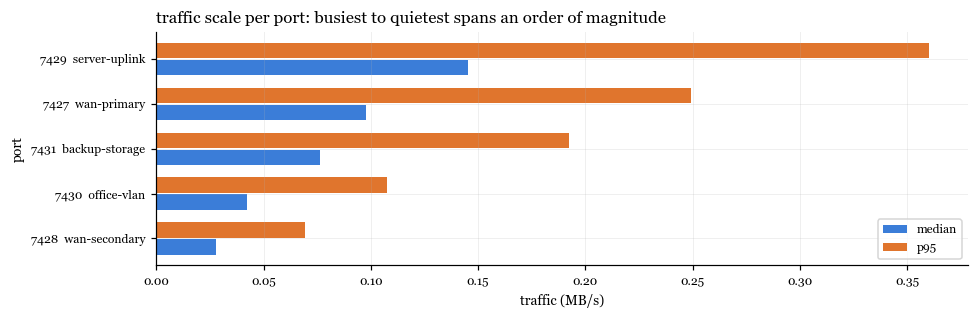

In [9]:
# Per-port traffic scale. A single global threshold ("alert above X Mbps")
# cannot work here: the busiest and quietest ports differ by close to an
# order of magnitude, which is exactly why every baseline below normalizes
# per port instead of comparing raw levels across ports.
labels = [f"{r.port_id[-4:]}  {r.port_role}" for r in inventory.itertuples()]
y = np.arange(len(inventory))

fig, ax = plt.subplots(figsize=(9, 3.0))
ax.barh(y - 0.19, inventory["median_MBps"], height=0.34,
        color=PALETTE["signal"], label="median")
ax.barh(y + 0.19, inventory["p95_MBps"], height=0.34,
        color=PALETTE["baseline"], label="p95")
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("traffic (MB/s)")
ax.set_ylabel("port")
ax.set_title("traffic scale per port: busiest to quietest spans an order of magnitude")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

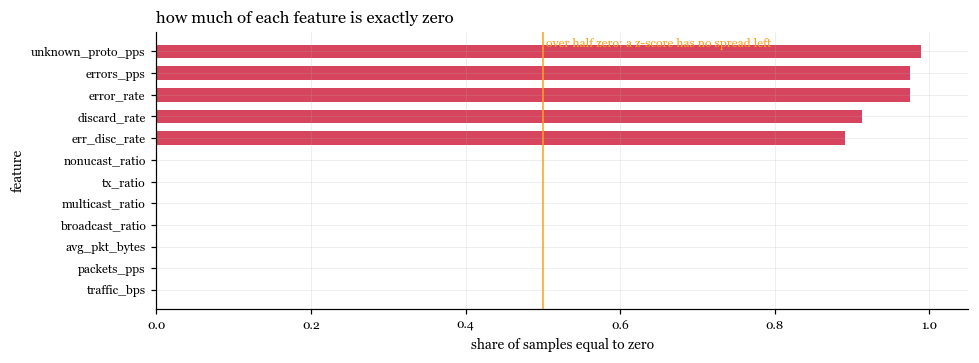

In [10]:
# Share of samples that are exactly zero, per feature. This is the practical
# test for whether a z-score means anything on that column: once too many
# samples sit at zero, the rolling scale estimate collapses toward zero and
# any non-zero reading gets inflated into an arbitrarily large score.
order = zero_frac.sort_values()
colors = [PALETTE["alert"] if v > 0.5 else PALETTE["signal"] for v in order]

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(range(len(order)), order.to_numpy(), color=colors, height=0.62)
ax.axvline(0.5, color=PALETTE["truth"], lw=1.0)
ax.text(0.5, len(order) - 0.4, " over half zero: a z-score has no spread left", fontsize=8,
        color=PALETTE["truth"], va="top")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order.index, fontsize=8)
ax.set_xlim(0, 1.05)
ax.set_xlabel("share of samples equal to zero")
ax.set_ylabel("feature")
ax.set_title("how much of each feature is exactly zero")
fig.tight_layout()
plt.show()

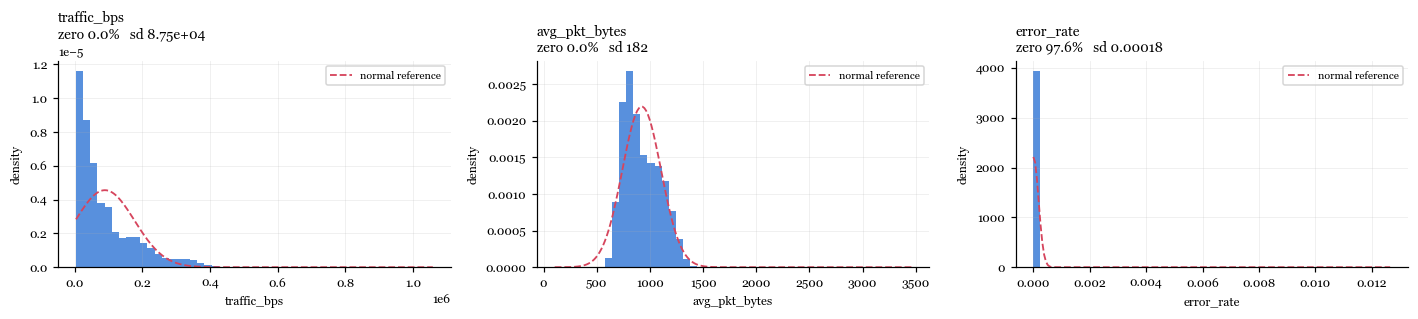

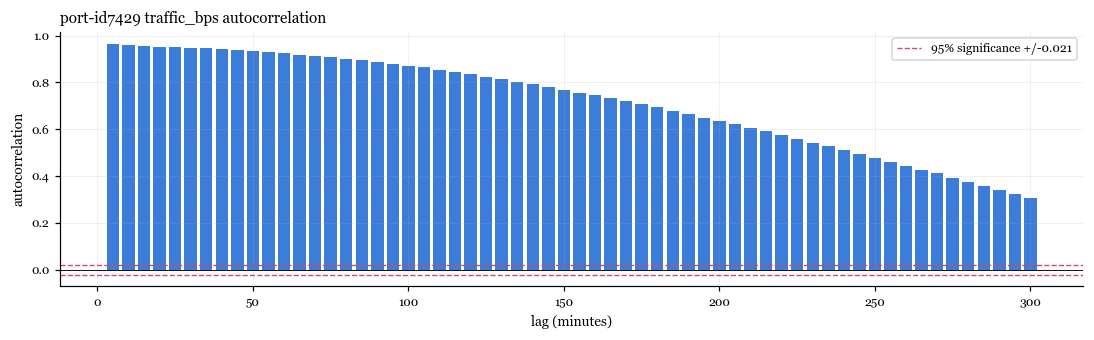

In [11]:
def single_port(telemetry, port_id=None):
    if port_id is None:
        port_id = telemetry["port_id"].value_counts().index[0]
    return telemetry[telemetry["port_id"] == port_id].sort_values("timestamp").reset_index(drop=True)

# Histogram against a normal reference curve. The gap between them is exactly
# how much a z-score on this column can be trusted: a good fit means a z-score
# is a meaningful anomaly signal, a poor fit (e.g. a spike at zero) means it is
# not, and that column needs a fixed threshold instead (see the degenerate-scale
# section later).
fig, axes = plt.subplots(1, 3, figsize=(13, 3.0))
for ax, column in zip(axes, ["traffic_bps", "avg_pkt_bytes", "error_rate"]):
    values = telemetry[column].dropna()
    ax.hist(values, bins=50, density=True, color="#3B7DD8", alpha=0.85)
    mu, sd = values.mean(), values.std()
    if sd > 0:
        grid = np.linspace(values.min(), values.max(), 200)
        ax.plot(grid, np.exp(-0.5 * ((grid - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi)),
                color="#D6455D", ls="--", lw=1.2, label="normal reference")
        ax.legend(fontsize=7)
    ax.set_title(f"{column}\nzero {(values == 0).mean():.1%}   sd {sd:.3g}",
                 fontsize=9, loc="left")
    ax.set_xlabel(column, fontsize=8)
    ax.set_ylabel("density", fontsize=8)
    ax.grid(alpha=0.2, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

# Autocorrelation, x-axis converted to minutes (easier to read than raw lag
# count). This sets a hard floor on the rolling window length any baseline
# can use: a window shorter than the strongest real periodicity found here
# will treat the daily traffic cycle itself as an anomaly, producing false
# alarms every day at the same time.
acf_series = single_port(telemetry, "port-id7429")["traffic_bps"]
lags = range(1, 61)
acf = [acf_series.autocorr(lag=k) for k in lags]
confidence = 1.96 / np.sqrt(len(acf_series))  # 95% significance band under the white-noise null; bars beyond it are real periodicity, not noise

fig, ax = plt.subplots(figsize=(12, 3.0))
ax.bar([k * CADENCE_S / 60 for k in lags], acf, width=CADENCE_S / 60 * 0.8,
       color=["#3B7DD8" if abs(v) > confidence else "#9AA4B0" for v in acf])  # blue bars are statistically significant lags
ax.axhline(confidence, color="#D6455D", ls="--", lw=0.9,
           label=f"95% significance +/-{confidence:.3f}")
ax.axhline(-confidence, color="#D6455D", ls="--", lw=0.9)
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("lag (minutes)", fontsize=9)
ax.set_ylabel("autocorrelation", fontsize=9)
ax.set_title("port-id7429 traffic_bps autocorrelation", loc="left", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.2, lw=0.6)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.show()

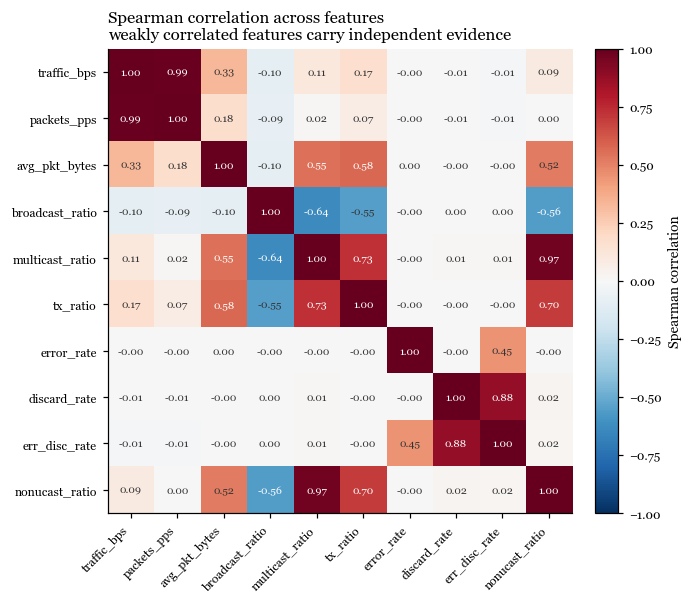

In [12]:
CORR_FEATURES = ["traffic_bps", "packets_pps", "avg_pkt_bytes", "broadcast_ratio",
                 "multicast_ratio", "tx_ratio", "error_rate", "discard_rate",
                 "err_disc_rate", "nonucast_ratio"]
corr = telemetry[CORR_FEATURES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(6.6, 5.6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_FEATURES)))
ax.set_xticklabels(CORR_FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(CORR_FEATURES)))
ax.set_yticklabels(CORR_FEATURES)
for i in range(len(CORR_FEATURES)):
    for j in range(len(CORR_FEATURES)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.55 else "#333333", fontsize=7)
ax.set_title("Spearman correlation across features\n"
             "weakly correlated features carry independent evidence")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")
fig.tight_layout()
plt.show()

## 2. 資料集不變量與參數設定

從資料剖面提煉出的關鍵特性：

* **退化特徵（Degenerate Features）：** `error_rate` 與 `errors_pps` 有 97.6% 的樣本為 0；`unknown_proto_pps` 達 99.0%；`discard_rate` 為 91.3%。滾動離散度在這些指標上會直接塌陷。
* **連續特徵（Continuous Features）：** `traffic_bps`、`packets_pps`、`avg_pkt_bytes`、`broadcast_ratio`、`multicast_ratio` 與 `tx_ratio` 無 Null 值亦無零值塌陷，適合計算統計分數。
* **取樣不變量：** 間隔為 300 秒（每小時 12 筆，每天 288 筆）。視窗參數必須依間隔換算。最短的事件（事件 E）僅持續 8 筆，這直接限制了 Lab 02 中連續確認（Confirmation Rule）筆數 $N$ 的上限。
* **類別不平衡（Class Imbalance）：** 43,200 筆資料中僅 286 筆落在事件時窗內（0.66%）。1% 的誤報率就會產生 432 則告警，數量比實際事件樣本還多。

## 3. Ground Truth 事件與變更日曆

Ground Truth Catalog 定義了 10 個事件（A 至 J）。其中 Broadcast Storm（事件 G）與 Multicast Flooding（事件 H）同時影響 5 個 Port，因此展開為 18 個獨立的 `(event, port)` 評估時窗。

`split_events()` 將這 18 個時窗與 `change_calendar.csv` 比對：

* **非預期事故（16 個時窗）：** 偵測器必須抓到的 Target Incidents。
* **計畫性變更（2 個時窗）：** 已預先登記的 Planned Changes，偵測器對此必須抑制告警（Suppressed）。

計畫性變更（事件 A 對應 CH-02、事件 C 對應 CH-01）在原始 Telemetry 中的表現與非預期事故完全相同，必須依賴維運脈絡才能正確抑制。

In [13]:
def load_events(telemetry, catalog_path=None):
    """Ground-truth event windows, one row per (event, port), from the label column.

    This is the target the whole lab is scored against: event recall in Lab 02
    is "how many of these windows did the detector fire an alert inside," not
    a per-sample metric.
    """
    lab = telemetry[telemetry["event_label"] != "normal"].copy()  # every row the simulator tagged as part of an event
    cols = ["event_id", "event_type", "device_id", "port_id", "port_role",
            "start", "end", "n_points", "description"]
    if lab.empty:
        return pd.DataFrame(columns=cols)
    g = lab.groupby(["event_id", "event_label", "device_id", "port_id", "port_role"], observed=True)
    ev = g.agg(start=("timestamp", "min"), end=("timestamp", "max"),
               n_points=("timestamp", "size")).reset_index().rename(columns={"event_label": "event_type"})  # collapse the labelled rows into one (start, end) window per (event, port)
    catalog_path = (DATA / "synthetic_event_catalog.csv") if catalog_path is None else catalog_path
    try:
        cat = pd.read_csv(catalog_path)
        desc = dict(zip(cat["event_id"].astype(str), cat["description"].astype(str)))
    except (FileNotFoundError, KeyError):
        desc = {}  # description is cosmetic; a missing catalog file must not break event loading
    ev["description"] = ev["event_id"].astype(str).map(desc).fillna("")
    return ev.sort_values("start").reset_index(drop=True)


def load_change_calendar(path=None):
    """Planned changes and maintenance windows; an alert inside one is a suppression failure.

    This is the piece that turns "detected an anomaly" into "should have notified
    someone": a real anomaly that coincides with a declared change is not a miss
    to fix, it is correct behaviour to suppress.
    """
    path = (DATA / "change_calendar.csv") if path is None else path
    cal = pd.read_csv(path, parse_dates=["start_time", "end_time"])
    return cal.rename(columns={"start_time": "start", "end_time": "end"}).sort_values("start").reset_index(drop=True)


def scope_matches(scope, device_id, port_id):
    """Whether a change-calendar entry's declared scope covers this device/port."""
    scope = str(scope)
    return scope in ("ALL", "*") or scope == device_id or scope == port_id


def split_events(events, calendar):
    """Separate events a detector must catch from planned ones it must stay quiet about.

    Same raw traffic shape either way: nothing in the telemetry itself
    distinguishes a real incident from a declared change. Only the calendar
    tells them apart, which is why this split exists as a separate step from
    detection.
    """
    planned = pd.Series(False, index=events.index)
    matched = pd.Series("", index=events.index)
    for ch in calendar.itertuples():
        for i, e in events.iterrows():
            if planned.loc[i] or not scope_matches(ch.scope, e["device_id"], e["port_id"]):
                continue
            if e["start"] <= ch.end and e["end"] >= ch.start:  # time-window overlap between the event and the declared change
                planned.loc[i] = True
                matched.loc[i] = str(ch.change_id)
    incidents = events[~planned].reset_index(drop=True)  # must be detected
    pl = events[planned].copy()  # must stay quiet
    pl["change_id"] = matched[planned].to_numpy()
    return incidents, pl.reset_index(drop=True)

events = load_events(telemetry)
calendar = load_change_calendar()
incidents, planned = split_events(events, calendar)

print(f"(event, port) windows  {len(events)}"
      f"   incidents 必須抓到 {len(incidents)}   planned 必須安靜 {len(planned)}")
print("planned:", ", ".join(f"{r.event_id} {r.event_type} ({r.change_id})"
                            for r in planned.itertuples()))

(event, port) windows  18   incidents 必須抓到 16   planned 必須安靜 2
planned: A business_traffic_growth (CH-02), C large_file_backup (CH-01)


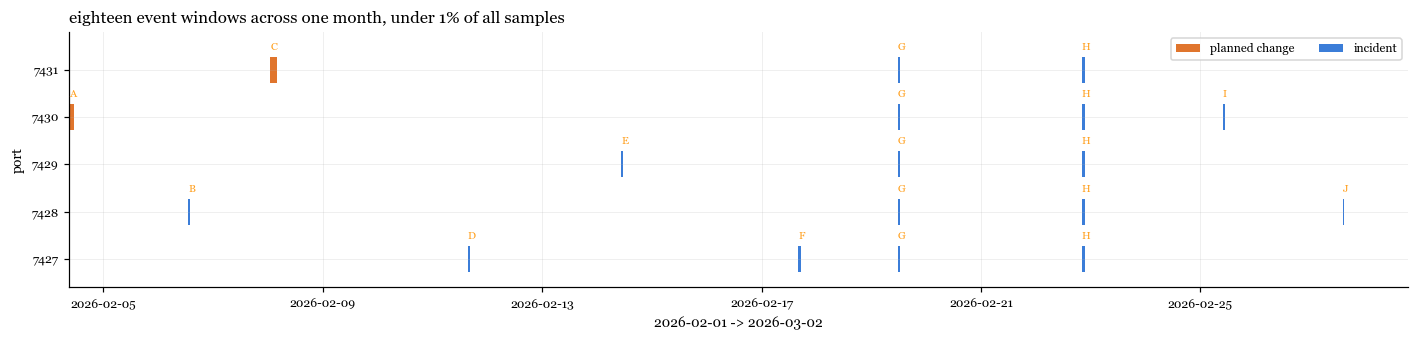

In [14]:
# Gantt view of every event window: same shape in the raw traffic whether it
# is a real incident (must alert) or a planned change (must stay quiet). A
# detector with no change calendar cannot tell these apart from the data alone.
planned_ids = set(planned["event_id"])
ports = sorted(telemetry["port_id"].unique())
row = {p: n for n, p in enumerate(ports)}

fig, ax = plt.subplots(figsize=(13, 3.2))
for e in events.itertuples():
    is_planned = e.event_id in planned_ids
    ax.barh(row[e.port_id], e.end - e.start, left=e.start, height=0.55,
            color=PALETTE["baseline"] if is_planned else PALETTE["signal"],
            label="planned change" if is_planned else "incident")
    ax.text(e.start, row[e.port_id] + 0.38, e.event_id, fontsize=7,
            color=PALETTE["truth"], ha="left", va="bottom")

handles, labels_ = ax.get_legend_handles_labels()
uniq = dict(zip(labels_, handles))
ax.legend(uniq.values(), uniq.keys(), loc="upper right", ncol=2)
ax.set_yticks(range(len(ports)))
ax.set_yticklabels([p[-4:] for p in ports], fontsize=8)
ax.set_ylim(-0.6, len(ports) - 0.2)
ax.set_xlabel("2026-02-01 -> 2026-03-02")
ax.set_ylabel("port")
ax.set_title("eighteen event windows across one month, under 1% of all samples")
fig.tight_layout()
plt.show()

## 4. 把 Mean 換成 Median

$(x-\text{中心})/\text{尺度}$ 解決了跨 port 的尺度問題，但還有三個獨立的問題同時待解，混淆它們是這類 pipeline 最常見的設計失誤：

1. **到底該測量哪個原始訊號**
2. 對於那個訊號，**什麼才算中心和尺度**
3. **需要多少連續樣本、什麼策略**

第 1 步：`traffic_bps` 配 Rolling Mean，18 個事件時窗一個都沒抓到，而且連一個正常樣本都沒有跨過同一個門檻，代表這個門檻在這個 Baseline 上幾乎沒被觸發過。

第 2 步：把 Mean／$\sigma$ 換成 Median／MAD（$1.4826 \times \text{MAD}$），分數的形狀 $(x-\text{center})/\text{scale}$ 完全不動，只換了 center 跟 scale 兩個估計量的算法。

| 策略 | 方法論 | 缺點 / 邊界條件 |
| --- | --- | --- |
| **Rolling Mean** | 以近期歷史計算 Mean 與 $\sigma$。 | |
| **Rolling Robust** | 以近期歷史計算 Median 與 MAD。 | 較不受 Dirty History 影響，直到異常樣本超過視窗長度的 50%。 |
| **Seasonal** | 按工作日/週末與小時分組計算。 | 不受近期歷史飄移影響；但依賴乾淨的歷史 Profile 資料。 |
| **Peer Group** | 同一時間點對其他 Port 進行 Leave-one-out 比較。 | 無法察覺全域性（Estate-wide）同時發生的整體位移。 |

*註：Rolling 與 Seasonal 可在單一 Port 計算；Peer 必須等 5 個 Port 資料匯總後才能計算。Seasonal 與 Peer 留在這裡，不是要跟 Robust 比高下，是各自回答一個 Robust 答不了的問題，第 5 節會看到。*

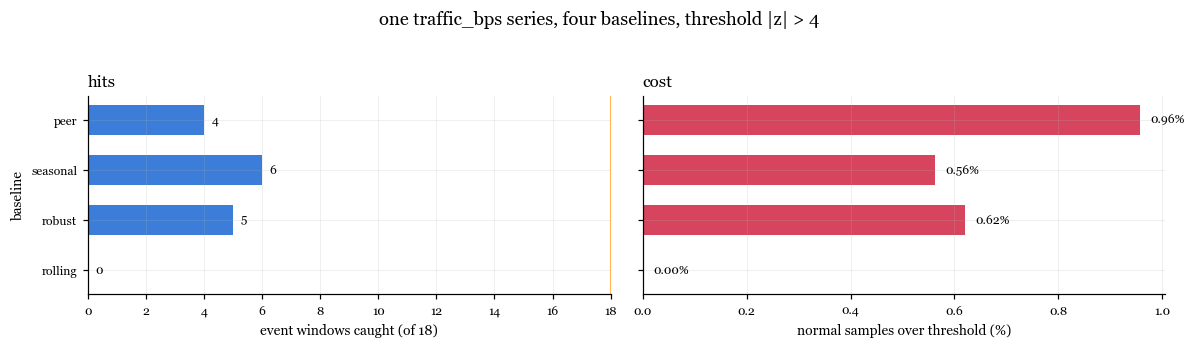

In [175]:
def global_scale(values):
    """Scale estimator: MAD rescaled to a Gaussian-consistent standard deviation,
    with fallbacks when the series is degenerate."""
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]  # drop NaN/Inf before computing order statistics
    if x.size == 0:
        return 0.0
    mad = float(np.median(np.abs(x - np.median(x)))) * MAD_TO_SIGMA  # MAD, rescaled by the normal-consistency factor 1.4826
    if mad > 0:
        return mad  # primary estimator when non-degenerate
    std = float(np.std(x))  # fallback: population standard deviation
    return std if std > 0 else 0.01 * float(np.mean(np.abs(x)))  # final fallback: fixed fraction of mean absolute value, avoids a zero scale


def scale_floor(values, fraction=0.05):
    """Lower bound for any score denominator: a fixed fraction of the series' overall spread."""
    return max(fraction * global_scale(values), 1e-12)  # 1e-12 guards a fully constant series


def _floor_scale(scale, values, fraction=0.05):
    """Apply the floor to a per-sample scale series: fill missing values, clip below the floor."""
    floor = scale_floor(values, fraction)
    return scale.fillna(floor).clip(lower=floor)


def rolling_mean(values, window, min_periods=None):
    """Center/scale estimator: rolling arithmetic mean and rolling standard deviation."""
    mp = min_periods or max(3, window // 3)  # minimum samples required before the window is valid
    return values.rolling(window, min_periods=mp).mean(), _floor_scale(
        values.rolling(window, min_periods=mp).std(), values)


def rolling_robust(values, window, min_periods=None):
    """Center/scale estimator: rolling median and rolling MAD, both order-statistic
    based and resistant to outliers within the window."""
    mp = min_periods or max(3, window // 3)
    center = values.rolling(window, min_periods=mp).median()  # center: rolling median
    mad = (values - center).abs().rolling(window, min_periods=mp).median()  # scale: rolling median absolute deviation from that center
    return center, _floor_scale(mad * MAD_TO_SIGMA, values)  # rescale by the normal-consistency factor


def _season_key(ts, by):
    """Construct the grouping key that defines one recurring seasonal bucket."""
    if by == "hour":
        return ts.dt.hour.astype(str)  # key: hour of day
    if by == "daytype_hour":
        daytype = np.where(ts.dt.dayofweek >= 5, "weekend", "weekday")
        return pd.Series(daytype, index=ts.index) + "-" + ts.dt.hour.astype(str).str.zfill(2)  # key: weekday/weekend x hour of day
    if by == "dow_hour":
        return ts.dt.dayofweek.astype(str) + "-" + ts.dt.hour.astype(str).str.zfill(2)  # key: day of week x hour of day
    if by == "tod":
        return ts.dt.strftime("%H:%M")  # key: time of day, calendar date ignored
    raise ValueError(f"unknown seasonal key: {by}")


def seasonal(frame, value_col, by="daytype_hour", ts_col="timestamp", train_mask=None, min_samples=8):
    """Center/scale estimator: median and MAD computed within each recurring seasonal
    bucket, not over a sliding window."""
    values = frame[value_col].astype(float)
    key = _season_key(frame[ts_col], by)  # assign every sample to its seasonal bucket
    source = key if train_mask is None else key.where(train_mask)  # optionally restrict bucket statistics to a training subset
    g = values.groupby(source, observed=True)
    center_map, mad_map, counts = g.median(), g.apply(lambda s: (s - s.median()).abs().median()) * MAD_TO_SIGMA, g.size()  # per-bucket median, rescaled MAD, sample count
    thin = counts[counts < min_samples].index  # buckets with insufficient samples for a stable estimate
    center_map = center_map.drop(index=thin, errors="ignore")
    mad_map = mad_map.drop(index=thin, errors="ignore")
    center = key.map(center_map).fillna(values.median())  # per-sample center from its bucket, global median fallback for dropped buckets
    return center, _floor_scale(key.map(mad_map), values)


def peer(frame, value_col, ts_col="timestamp", unit_col="port_id", leave_one_out=True):
    """Center/scale estimator: cross-sectional median and MAD across peer units at
    each timestamp."""
    wide = frame.pivot_table(index=ts_col, columns=unit_col, values=value_col, aggfunc="mean")  # reshape to a timestamp x unit matrix
    m = wide.to_numpy(dtype=float)
    centers, scales = np.empty_like(m), np.empty_like(m)
    for j in range(m.shape[1]):
        others = np.delete(m, j, axis=1) if (leave_one_out and m.shape[1] > 1) else m  # exclude the unit's own column, leave-one-out
        med = np.nanmedian(others, axis=1)  # cross-sectional median at each timestamp
        mad = np.nanmedian(np.abs(others - med[:, None]), axis=1) * MAD_TO_SIGMA  # cross-sectional MAD, rescaled
        centers[:, j], scales[:, j] = med, mad
    cw = pd.DataFrame(centers, index=wide.index, columns=wide.columns)
    sw = pd.DataFrame(scales, index=wide.index, columns=wide.columns)
    idx = pd.MultiIndex.from_arrays([frame[ts_col], frame[unit_col]])
    center = pd.Series(cw.stack().reindex(idx).to_numpy(), index=frame.index)  # map back to the original row order
    scale = pd.Series(sw.stack().reindex(idx).to_numpy(), index=frame.index)
    return center, _floor_scale(scale, frame[value_col].astype(float))


def deviation_score(values, center, scale, signed=True, cap=MAX_SCORE):
    """Normalization step: (value - center) / scale, clipped to +/-cap."""
    s = ((values - center) / scale).clip(lower=-cap, upper=cap)  # standardized deviation, symmetric clip bounds outliers
    return s if signed else s.abs()  # signed score or its magnitude

def truth_mask(frame, events):
    """Boolean per-sample ground truth aligned to `frame`."""
    mask = pd.Series(False, index=frame.index)
    for e in events.itertuples():
        mask |= ((frame["port_id"] == e.port_id) & (frame["timestamp"] >= e.start)
                 & (frame["timestamp"] <= e.end))
    return mask

frames = []
for port_id, group in telemetry.groupby("port_id", observed=True):
    g = group.sort_values("timestamp").reset_index(drop=True)

    rc, rs = rolling_mean(g["traffic_bps"], WINDOW)
    g["roll_center"], g["roll_lo"], g["roll_hi"] = rc, rc - 3 * rs, rc + 3 * rs
    g["z_rolling"] = deviation_score(g["traffic_bps"], rc, rs)

    bc, bs = rolling_robust(g["traffic_bps"], WINDOW)
    g["robust_center"], g["robust_lo"], g["robust_hi"] = bc, bc - 3 * bs, bc + 3 * bs
    g["z_robust"] = deviation_score(g["traffic_bps"], bc, bs)

    sc, ss = seasonal(g, "traffic_bps", by="daytype_hour")
    g["seasonal_center"], g["seasonal_lo"], g["seasonal_hi"] = sc, sc - 3 * ss, sc + 3 * ss
    g["z_seasonal"] = deviation_score(g["traffic_bps"], sc, ss)

    frames.append(g)

feat = pd.concat(frames, ignore_index=True)

pc, ps = peer(feat, "traffic_bps")
feat["peer_center"], feat["peer_lo"], feat["peer_hi"] = pc, pc - 3 * ps, pc + 3 * ps
feat["z_peer"] = deviation_score(feat["traffic_bps"], pc, ps)

BASELINES = ["z_rolling", "z_robust", "z_seasonal", "z_peer"]
truth = truth_mask(feat, events)

rows = []
for b in BASELINES:
    fired = feat[b].abs() > 4
    caught = sum(
        1 for e in events.itertuples()
        if fired[(feat["port_id"] == e.port_id)
                 & (feat["timestamp"] >= e.start)
                 & (feat["timestamp"] <= e.end)].any()
    )
    rows.append({
        "baseline": b.replace("z_", ""),
        "caught": caught,
        "normal_over_4_pct": 100 * fired[~truth].mean(),
    })
compare = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.0), sharey=True)
y = np.arange(len(compare))

axes[0].barh(y, compare["caught"], color=PALETTE["signal"], height=0.6)
axes[0].set_xlim(0, len(events))
axes[0].axvline(len(events), color=PALETTE["truth"], lw=1.0)
for n, v in enumerate(compare["caught"]):
    axes[0].text(v + 0.25, n, str(v), va="center", fontsize=8)
axes[0].set_yticks(y); axes[0].set_yticklabels(compare["baseline"])
axes[0].set_xlabel(f"event windows caught (of {len(events)})")
axes[0].set_ylabel("baseline")
axes[0].set_title("hits")

axes[1].barh(y, compare["normal_over_4_pct"], color=PALETTE["alert"], height=0.6)
for n, v in enumerate(compare["normal_over_4_pct"]):
    axes[1].text(v + 0.02, n, f"{v:.2f}%", va="center", fontsize=8)
axes[1].set_xlabel("normal samples over threshold (%)")
axes[1].set_title("cost")

fig.suptitle("one traffic_bps series, four baselines, threshold |z| > 4", y=1.04)
fig.tight_layout()
plt.show()

### **Ablation：**

* Parameter：`WINDOW`（1h／12 筆）與比較用的閾值 `4`，兩個都是寫死的常數。
* Architecture：`BASELINES` 是四選一或疊加；`seasonal()` 的 `by=` 可以換成 `hour`、`dow_hour`、`tod`，換一種相位定義。
* Per-port：目前 5 個 port 共用同一個 `WINDOW`；流量差一個數量級的 port（第 1 節那張表）不一定該用同一個視窗長度，可以把 `WINDOW` 改成依 port 查表。
* Adaptive：`WINDOW` 可以用第 1 節算出來的自相關結果，逐 port 動態定出來，而不是全部寫死 12。

## 5. 第 2 步的證據：同一段事件，四種讀法

評估 `port-id7431` 上的事件 C（`large_file_backup`，事件長度 36 筆，對比視窗 12 筆），四個子圖由上而下對照：

1. **Rolling Mean：** 高流量事件進入後，期望區間（Band）迅速被拉寬，Center 被拉高，導致後半段的 Z-score 被抑制。這就是第 4 節那個 0/18 的機制，在單一事件上放大來看。
2. **Rolling Robust：** 中位數能在半個視窗長度（$W/2$）內保持不動，維持高偏差分數，直到異常點過半才修正。這是第 4 節 5/18 的來源。
3. **Seasonal（另一個視角）：** 完全不受短期歷史影響。能正確掌握時間週期（Time-of-day），適合辦公室 VLAN（如 `port-id7430`）等具強烈日週期的流量。
4. **Peer（另一個視角）：** 當事件同時打在所有 Port 上時失效。所有 Peer 一起抬升時，同儕間的相對變異數會歸零。

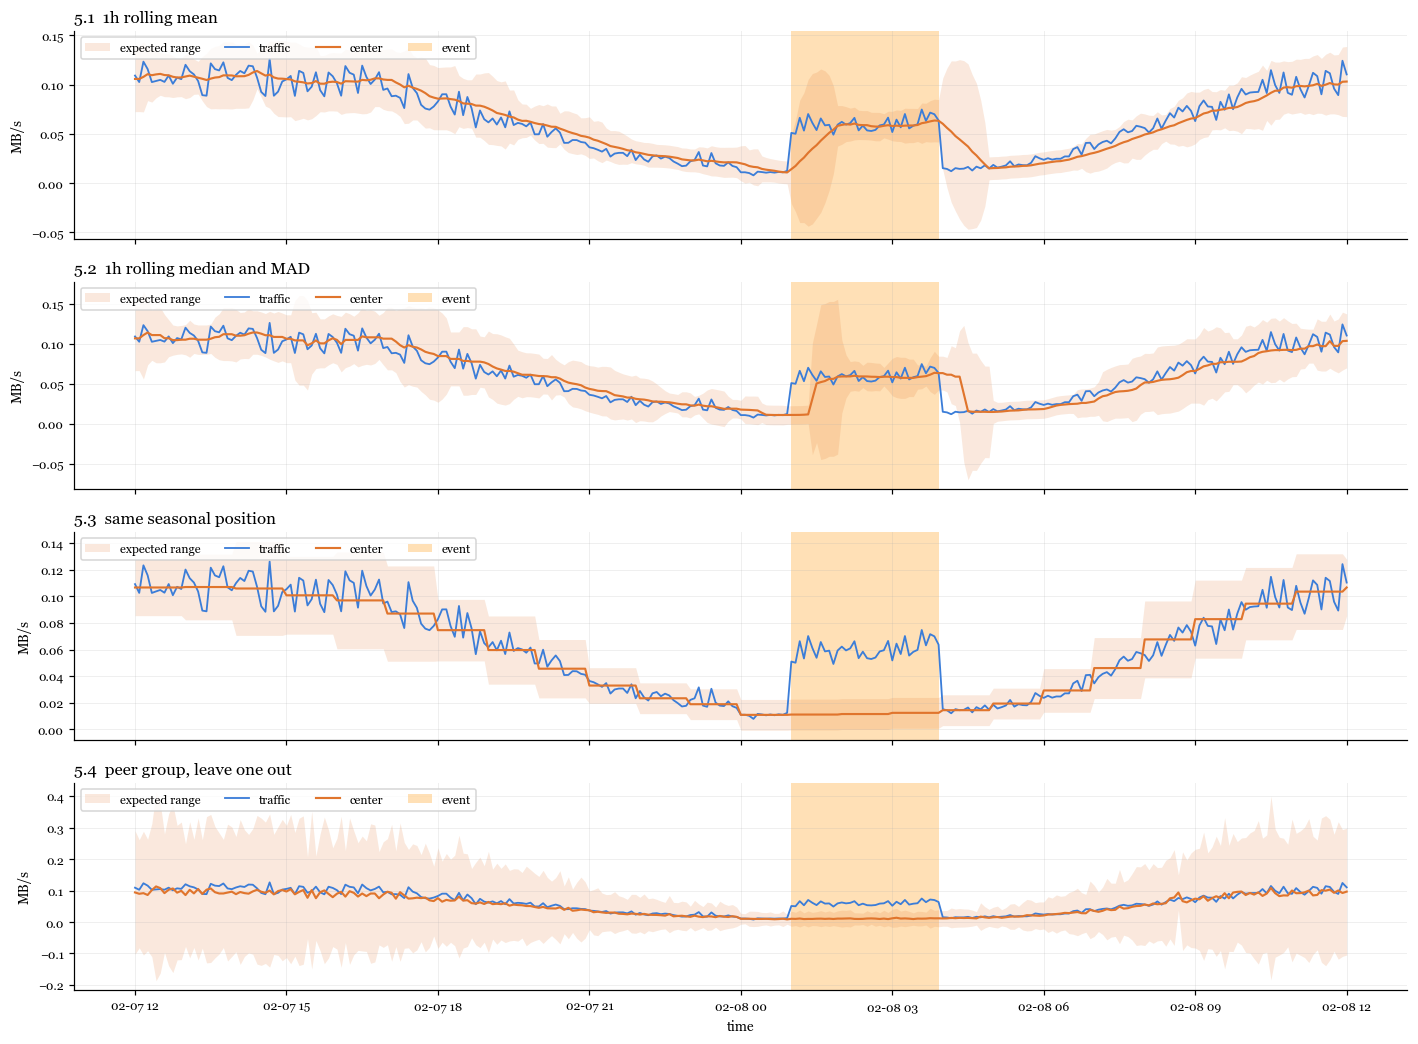

expected-range width in MB/s over this window
      roll  robust  seasonal   peer
50%  0.044   0.059     0.044  0.222
max  0.168   0.193     0.073  0.600


In [18]:
LOOK_PORT = "port-id7431"
LOOK_FROM, LOOK_TO = "2026-02-07 12:00", "2026-02-08 12:00"

feat["is_incident"] = truth_mask(feat, events)
view = feat[(feat["port_id"] == LOOK_PORT)
            & (feat["timestamp"] >= LOOK_FROM)
            & (feat["timestamp"] <= LOOK_TO)].reset_index(drop=True)

PANELS = [("roll", "5.1  1h rolling mean"),
          ("robust", "5.2  1h rolling median and MAD"),
          ("seasonal", "5.3  same seasonal position"),
          ("peer", "5.4  peer group, leave one out")]

fig, axes = plt.subplots(len(PANELS), 1, figsize=(13, 2.4 * len(PANELS)), sharex=True)
for ax, (key, title) in zip(axes, PANELS):
    ax.fill_between(view["timestamp"], view[f"{key}_lo"] / 1e6, view[f"{key}_hi"] / 1e6,
                    color="#E0752D", alpha=0.16, lw=0, label="expected range")
    ax.plot(view["timestamp"], view["traffic_bps"] / 1e6,
            color="#3B7DD8", lw=1.2, label="traffic")
    ax.plot(view["timestamp"], view[f"{key}_center"] / 1e6,
            color="#E0752D", lw=1.4, label="center")
    shade_truth(ax, view["timestamp"], view["is_incident"])
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_ylabel("MB/s", fontsize=9)
    ax.legend(fontsize=8, loc="upper left", ncol=4)
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[-1].set_xlabel("time")
fig.tight_layout()
plt.show()

# 帶的寬度本身就是一個可比較的量：帶越寬，同一筆偏離要越大才算數。
width = pd.DataFrame({key: (view[f"{key}_hi"] - view[f"{key}_lo"]) / 1e6
                      for key, _ in PANELS})
print("expected-range width in MB/s over this window")
print(width.describe().loc[["50%", "max"]].round(3).to_string())

## 開場：時間序列特徵工程的通用工具箱

下面這一步用到的技巧其實只有四個：**窗格化**（一個計算回溯多少歷史，每個 baseline 底下都是一種窗格的選擇）、**延遲特徵**（把 k 步前的值或差值當明確輸入，捕捉近期變化的形狀而非只跟平均值比）、**滾動統計**（滑動窗格上的平均值/標準差/中位數/MAD/分位數，§3 到 §5 每個 baseline 的直接機制）、**多解析度表示**（同時用多種窗格長度算同一個統計量，驅動 §8 的變點偵測）。先看到這四個詞，接下來的每個具體方法讀起來就是這四個想法的實例，不是各自獨立的新招。

## 6. 第 3 步：給偵測器加上它原本沒有的眼睛

單一特徵監控必然存在盲點。例如事件 B（`small_packet_scan`）的封包數增加 8 倍，但平均封包大小降至 1/6，兩者相乘後總頻寬 `traffic_bps` 幾乎沒有變化，這正是第 1、2 步一直在用的那個特徵。第 3 步把偵測器從一個特徵擴展到多特徵組合成的單一分數。

除了第 1 節已有的欄位，這裡再加入三個特徵，各自對應目錄裡尚未被覆蓋到的故障類型：`unknown_proto_pps`（事件 J `unknown_protocol_scan`，先前只在第 2、7 節的剖面裡出現過，從未真正進過消融實驗）、`err_disc_rate`（errors 與 discards 合併成單一訊號，對應 D `queue_congestion`／E `link_quality_issue`／F `load_sensitive_link_issue` 這一組線路品質故障）、`nonucast_ratio`（broadcast_ratio 與 multicast_ratio 合併，對應 G／H 的 flood 類事件）。合併是否比分開更好，不用猜，下一格先給一個真正的前後對照：只用 `traffic_bps` 一個特徵，在同一組門檻與確認筆數下能抓到幾個事件。

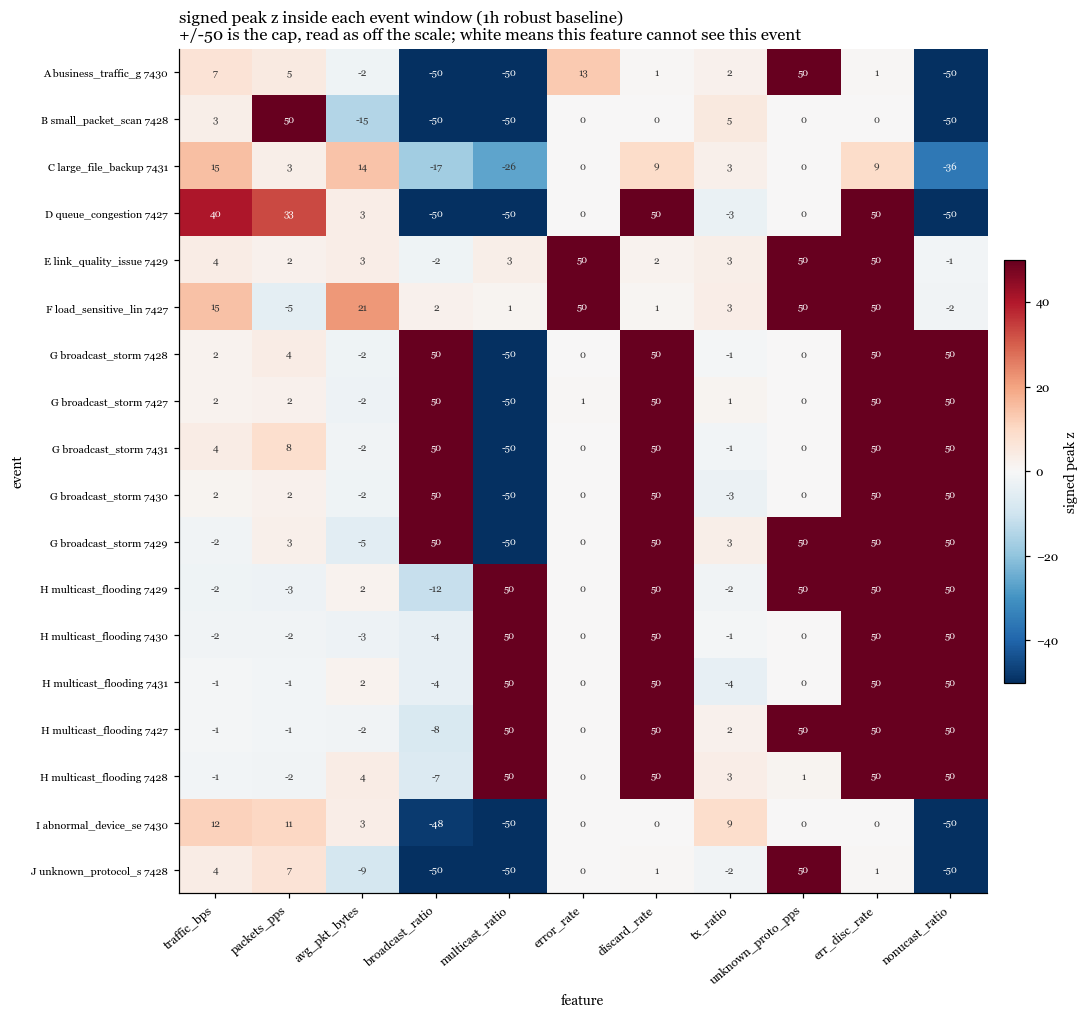

In [19]:
# traffic_bps 的 1h robust 分數第 4 節已經算過，這裡只補其餘十欄。
SHAPE_FEATURES = ["packets_pps", "avg_pkt_bytes", "broadcast_ratio",
                  "multicast_ratio", "error_rate", "discard_rate", "tx_ratio",
                  "unknown_proto_pps", "err_disc_rate", "nonucast_ratio"]
FEATURES = ["traffic_bps"] + SHAPE_FEATURES

scored = []
for port_id, group in telemetry.groupby("port_id", observed=True):
    g = group.sort_values("timestamp").reset_index(drop=True)
    for col in SHAPE_FEATURES:
        cen, sca = rolling_robust(g[col], WINDOW)
        g["z_" + col] = deviation_score(g[col], cen, sca)
    scored.append(g)
# 兩個迴圈的分組與排序相同，feat 的列序與 scored 一致。
scored = pd.concat(scored, ignore_index=True)
scored["z_traffic_bps"] = feat["z_robust"].to_numpy()


# 視窗內離 0 最遠的那一點，保留符號。
def signed_peak(series):
    return series.loc[series.abs().idxmax()]


rows = []
for e in events.itertuples():
    window = scored[(scored["port_id"] == e.port_id)
                    & (scored["timestamp"] >= e.start)
                    & (scored["timestamp"] <= e.end)]
    rows.append({"ev": f"{e.event_id} {e.event_type[:18]} {e.port_id[-4:]}",
                 **{col: signed_peak(window["z_" + col]) for col in FEATURES}})
peak = pd.DataFrame(rows).set_index("ev")

fig, ax = plt.subplots(figsize=(10, 0.42 * len(peak) + 1.8))
im = ax.imshow(peak.to_numpy(), cmap="RdBu_r", vmin=-50, vmax=50, aspect="auto")
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(peak))); ax.set_yticklabels(peak.index, fontsize=7)
ax.set_xlabel("feature")
ax.set_ylabel("event")
for r in range(peak.shape[0]):
    for c in range(peak.shape[1]):
        v = peak.iat[r, c]
        ax.text(c, r, f"{v:.0f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(v) > 28 else "#333333")
ax.grid(False)
ax.set_title("signed peak z inside each event window (1h robust baseline)\n"
             "+/-50 is the cap, read as off the scale; white means this feature cannot see this event")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="signed peak z")
fig.tight_layout()
plt.show()

下面把三個新特徵各自放到它們對應的事件時窗旁邊看：`unknown_proto_pps` 在事件 J，`err_disc_rate` 在事件 D（同一個特徵也是 E、F 的偵測依據），`nonucast_ratio` 在事件 G（同一個特徵也是 H 的偵測依據，5 個 port 疊在一起看，跟第 9 節 Collective Anomaly 那張圖同樣的畫法）。

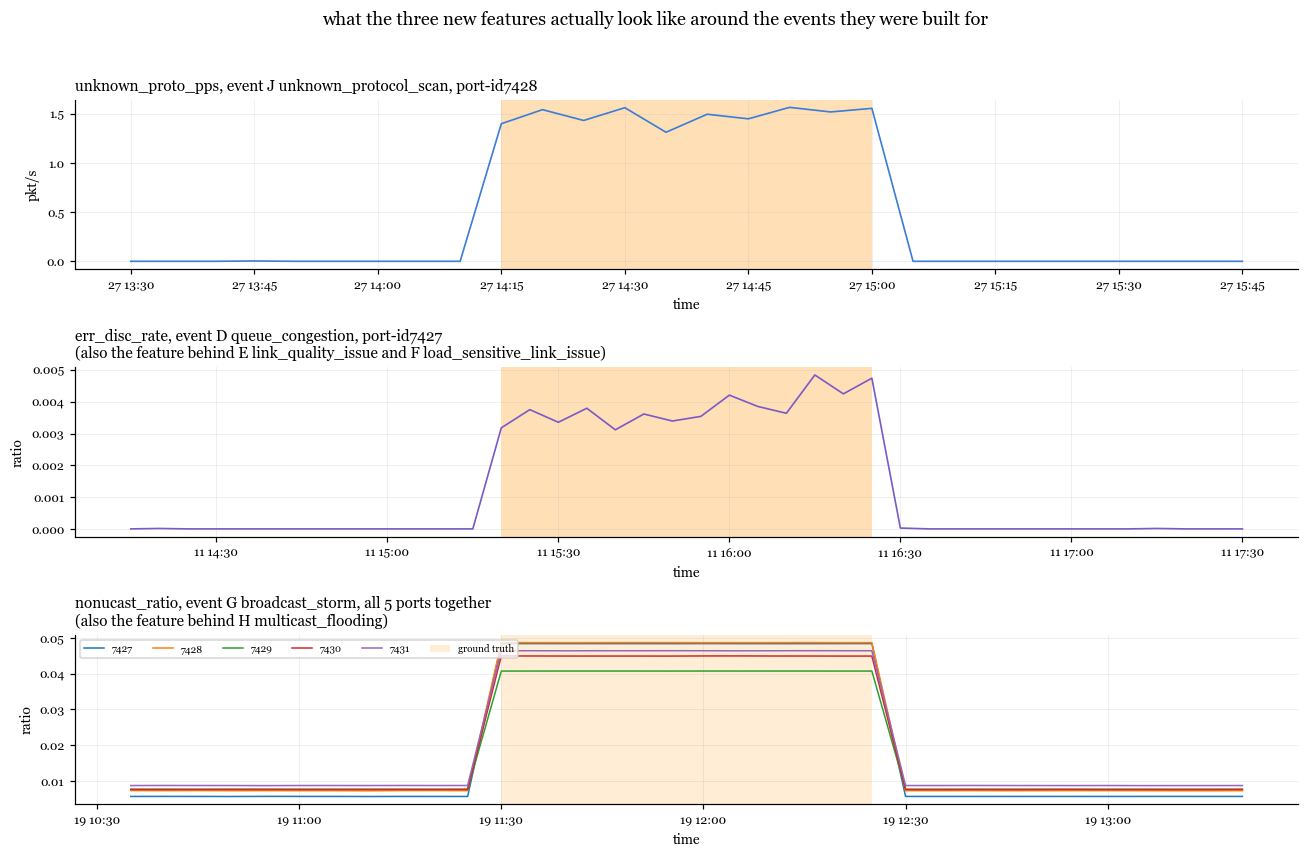

In [20]:
# Each panel is the feature that a traffic-only baseline cannot see the event
# through: event J (protocol scan) barely moves traffic_bps but is obvious in
# unknown_proto_pps; D/E/F (link-quality issues) show up in err_disc_rate, not
# in traffic volume; G/H (broadcast/multicast floods) show up in nonucast_ratio
# across every port at once. This is the case for building shape features at
# all, not just volume ones.
fig, axes = plt.subplots(3, 1, figsize=(12, 7.6))

ej = events[events["event_id"] == "J"].iloc[0]
pad = ej.end - ej.start
view = telemetry[(telemetry["port_id"] == ej.port_id)
                 & (telemetry["timestamp"] >= ej.start - pad)
                 & (telemetry["timestamp"] <= ej.end + pad)]
axes[0].plot(view["timestamp"], view["unknown_proto_pps"], color=PALETTE["signal"], lw=1.1)
shade_truth(axes[0], view["timestamp"], view["event_label"] != "normal")
axes[0].set_title(f"unknown_proto_pps, event J unknown_protocol_scan, {ej.port_id}", loc="left", fontsize=10)
axes[0].set_xlabel("time")
axes[0].set_ylabel("pkt/s")

ed = events[events["event_id"] == "D"].iloc[0]
pad = ed.end - ed.start
view = telemetry[(telemetry["port_id"] == ed.port_id)
                 & (telemetry["timestamp"] >= ed.start - pad)
                 & (telemetry["timestamp"] <= ed.end + pad)]
axes[1].plot(view["timestamp"], view["err_disc_rate"], color=PALETTE["score"], lw=1.1)
shade_truth(axes[1], view["timestamp"], view["event_label"] != "normal")
axes[1].set_title(f"err_disc_rate, event D queue_congestion, {ed.port_id}\n"
                  "(also the feature behind E link_quality_issue and F load_sensitive_link_issue)",
                  loc="left", fontsize=10)
axes[1].set_xlabel("time")
axes[1].set_ylabel("ratio")

eg = events[events["event_id"] == "G"]
g_start, g_end = eg["start"].min(), eg["end"].max()
pad = g_end - g_start
for pid in sorted(telemetry["port_id"].unique()):
    view = telemetry[(telemetry["port_id"] == pid)
                     & (telemetry["timestamp"] >= g_start - pad)
                     & (telemetry["timestamp"] <= g_end + pad)]
    axes[2].plot(view["timestamp"], view["nonucast_ratio"], lw=1.0, label=pid[-4:])
axes[2].axvspan(g_start, g_end, color=PALETTE["truth"], alpha=0.18, lw=0, label="ground truth")
axes[2].legend(fontsize=6.5, ncol=6, loc="upper left")
axes[2].set_title("nonucast_ratio, event G broadcast_storm, all 5 ports together\n"
                  "(also the feature behind H multicast_flooding)", loc="left", fontsize=10)
axes[2].set_xlabel("time")
axes[2].set_ylabel("ratio")

for ax in axes:
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.suptitle("what the three new features actually look like around the events they were built for", y=1.02)
fig.tight_layout()
plt.show()

### 第 4 步：只留下真的有在付出貢獻的特徵

十一個特徵一起上抓到 16/16 個事件；上一格印出來的單一特徵（`traffic_bps`）只抓到 3/16。多抓的 13 個事件不是免費的，每天的誤報數也跟著漲。這一步把「加了什麼」換成「加了要付多少代價」：針對多特徵最大值組合（門檻 $\vert z\vert > 4$、連續 2 筆確認），逐一拿掉每個特徵，量事件召回真的掉了多少。

* **邊際貢獻（Marginal Contribution）與代價：** 邊際貢獻為零的特徵分為兩類：一是能被其他特徵涵蓋的冗餘特徵；二是離散度塌陷、只會增加每日誤報卻無法提升 Recall 的退化特徵。
* **特徵篩選策略（Feature Selection）：** 移除冗餘與退化特徵能在完全不影響事件 Recall 的前提下，顯著降低每日誤報數（False Positive Rate）。

traffic_bps alone: 3/16 incident windows, 1.8 false alarms/day  <- what step 2 already had before this step



all 11 features: 16/16 incident windows, 23.9 false alarms/day
first 2 picked (multicast_ratio, error_rate): 16/16, 3.1 false alarms/day


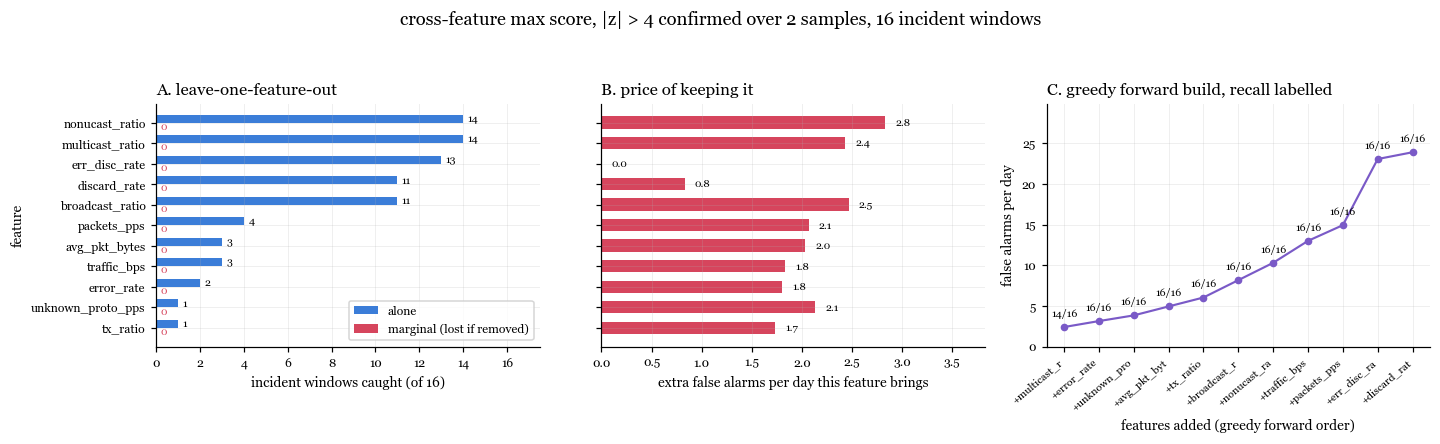

In [21]:
# 消融實驗：把十一個特徵合成一個 score_max，逐一拿掉，量事件召回掉多少。
ABL_TH, ABL_CONSEC = 4.0, 2

abl_truth = truth_mask(scored, events).to_numpy()
abl_port = scored["port_id"].to_numpy()
abl_z = {c: np.nan_to_num(scored["z_" + c].abs().to_numpy(), nan=-1.0) for c in FEATURES}
abl_span_days = (scored["timestamp"].max() - scored["timestamp"].min()).total_seconds() / 86400
abl_windows = [
    np.flatnonzero(((scored["port_id"] == e.port_id)
                    & (scored["timestamp"] >= e.start)
                    & (scored["timestamp"] <= e.end)).to_numpy())
    for e in incidents.itertuples()
]


def abl_audit(cols):
    """cross-feature max -> N 連續確認 -> (抓到的 incident 視窗數, 每日誤報筆數)。"""
    if not cols:
        return 0, 0.0
    breach = pd.Series(np.vstack([abl_z[c] for c in cols]).max(axis=0) > ABL_TH)
    ok = np.ones(len(breach), dtype=bool)
    for k in range(ABL_CONSEC):
        ok &= breach.groupby(abl_port).shift(k).fillna(False).to_numpy().astype(bool)
    caught = sum(1 for idx in abl_windows if ok[idx].any())
    return caught, ok[~abl_truth].sum() / abl_span_days


solo_traffic_recall, solo_traffic_fp = abl_audit(["traffic_bps"])
print(f"traffic_bps alone: {solo_traffic_recall}/{len(abl_windows)} incident windows, "
      f"{solo_traffic_fp:.1f} false alarms/day  <- what step 2 already had before this step")
print()

full_recall, full_fp = abl_audit(FEATURES)
rows = []
for c in FEATURES:
    loo_r, loo_fp = abl_audit([f for f in FEATURES if f != c])
    solo_r, _ = abl_audit([c])
    rows.append({"feature": c, "solo": solo_r, "marginal": full_recall - loo_r,
                 "fp_added": full_fp - loo_fp})
abl = pd.DataFrame(rows).sort_values(["solo", "marginal"]).reset_index(drop=True)

# 貪婪前向選取：每次加入使召回最高、誤報最低的那一欄。
picked, pool, path = [], list(FEATURES), []
while pool:
    best = max(pool, key=lambda c: (abl_audit(picked + [c])[0], -abl_audit(picked + [c])[1]))
    picked.append(best)
    pool.remove(best)
    r, f = abl_audit(picked)
    path.append({"n": len(picked), "added": best, "recall": r, "fp_per_day": f})
path = pd.DataFrame(path)
enough = path[path["recall"] == path["recall"].max()].iloc[0]

print(f"all {len(FEATURES)} features: {full_recall}/{len(abl_windows)} incident windows, "
      f"{full_fp:.1f} false alarms/day")
print(f"first {int(enough['n'])} picked ({', '.join(path['added'][:int(enough['n'])])}): "
      f"{int(enough['recall'])}/{len(abl_windows)}, {enough['fp_per_day']:.1f} false alarms/day")

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8))
y = np.arange(len(abl))
h = 0.38

axes[0].barh(y + h / 2, abl["solo"], height=h, color=PALETTE["signal"], label="alone")
axes[0].barh(y - h / 2, abl["marginal"], height=h, color=PALETTE["alert"],
             label="marginal (lost if removed)")
for n, (s, m) in enumerate(zip(abl["solo"], abl["marginal"])):
    axes[0].text(s + 0.2, n + h / 2, str(s), va="center", fontsize=7)
    axes[0].text(m + 0.2, n - h / 2, str(m), va="center", fontsize=7,
                 color=PALETTE["alert"] if m == 0 else "#333333")
axes[0].set_yticks(y)
axes[0].set_yticklabels(abl["feature"], fontsize=8)
axes[0].set_xlim(0, len(abl_windows) + 1.5)
axes[0].set_xlabel(f"incident windows caught (of {len(abl_windows)})")
axes[0].set_ylabel("feature")
axes[0].set_title("A. leave-one-feature-out")
axes[0].legend(loc="lower right")

axes[1].barh(y, abl["fp_added"], height=0.6, color=PALETTE["alert"])
for n, v in enumerate(abl["fp_added"]):
    axes[1].text(v + 0.1, n, f"{v:.1f}", va="center", fontsize=7)
axes[1].set_yticks(y)
axes[1].set_yticklabels([])
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_xlim(0, abl["fp_added"].max() * 1.35)
axes[1].set_xlabel("extra false alarms per day this feature brings")
axes[1].set_title("B. price of keeping it")

axes[2].plot(path["n"], path["fp_per_day"], marker="o", ms=4,
             color=PALETTE["score"], lw=1.4)
for r in path.itertuples():
    axes[2].annotate(f"{r.recall}/{len(abl_windows)}", (r.n, r.fp_per_day),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7)
axes[2].set_xticks(path["n"])
axes[2].set_xticklabels([f"+{a[:11]}" for a in path["added"]], rotation=40,
                        ha="right", fontsize=7)
axes[2].set_ylim(0, path["fp_per_day"].max() * 1.25)
axes[2].set_xlabel("features added (greedy forward order)")
axes[2].set_ylabel("false alarms per day")
axes[2].set_title("C. greedy forward build, recall labelled")

fig.suptitle(f"cross-feature max score, |z| > {ABL_TH:.0f} confirmed over "
             f"{ABL_CONSEC} samples, {len(abl_windows)} incident windows", y=1.05)
fig.tight_layout()
plt.show()

**旁註：完整核算的代價。** 上面的留一法只問「拿掉這一欄，召回率掉多少」。真正窮盡的做法，是算出每個特徵在所有 $2^n$ 種子集組合下的平均邊際貢獻，也就是正式的 Shapley 值：

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[v(S \cup \{i\}) - v(S)\right]$$

11 個特徵要跑 $2^{11}=2048$ 次重新評估，這裡不划算；特徵數一旦上看二十幾個，窮舉不可行，才需要 KernelSHAP 一類的抽樣近似。

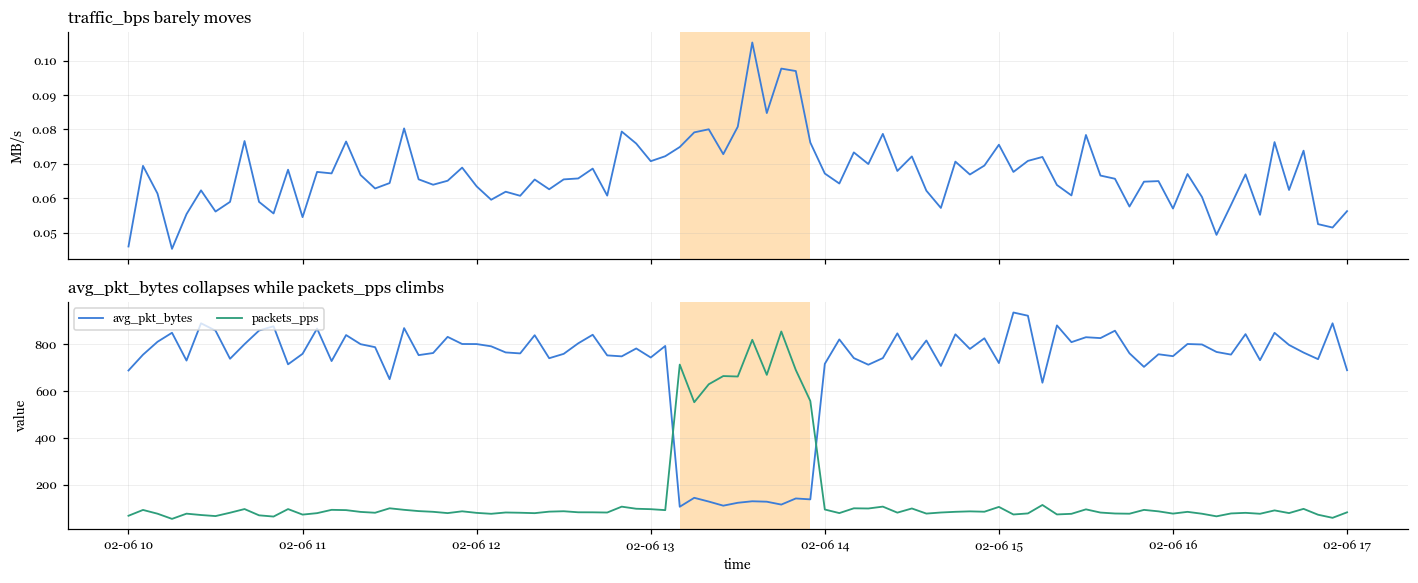

In [22]:
SCAN_PORT = "port-id7428"
scan = single_port(telemetry, SCAN_PORT)
scan["is_incident"] = truth_mask(scan, events)
bwin = scan[(scan["timestamp"] >= "2026-02-06 10:00")
            & (scan["timestamp"] <= "2026-02-06 17:00")].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(13, 5.4), sharex=True)

axes[0].plot(bwin["timestamp"], bwin["traffic_bps"] / 1e6, color="#3B7DD8", lw=1.2)
axes[0].set_title("traffic_bps barely moves", loc="left", fontsize=11)
axes[0].set_ylabel("MB/s", fontsize=9)

axes[1].plot(bwin["timestamp"], bwin["avg_pkt_bytes"],
             color="#3B7DD8", lw=1.2, label="avg_pkt_bytes")
axes[1].plot(bwin["timestamp"], bwin["packets_pps"],
             color="#2E9E7B", lw=1.2, label="packets_pps")
axes[1].set_title("avg_pkt_bytes collapses while packets_pps climbs", loc="left", fontsize=11)
axes[1].set_xlabel("time")
axes[1].set_ylabel("value")
axes[1].legend(fontsize=8, loc="upper left", ncol=3)

for ax in axes:
    shade_truth(ax, bwin["timestamp"], bwin["is_incident"])
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

### **消融實驗（Ablation Study）:**

* Parameter：`ABL_TH`（4.0）與 `ABL_CONSEC`（2），消融實驗的判定門檻。
* Architecture：`FEATURES` 清單本身可以增減；跨特徵合併目前是取 `max(|z|)`，換成加權平均或其他合併方式會改變整個消融結果。
* Per-port：貪婪前向選取（greedy forward selection）是把 5 個 port 混在一起選的；不同 port 的最佳特徵組合不一定相同，可以拆開來各自跑一次。

## 7. 第 5 步：任何 Z-score 都補不了的缺口

`error_rate` 與 `discard_rate` 等特徵長時間貼在 0。當滾動離散度（Scale）觸底時，標準的 Z-score 公式會失效：

$$\text{score} = \frac{x - \text{center}}{\text{scale}}$$

極小的分母會放大所有非零值，使其直接頂到上限（`MAX_SCORE = 50.0`）。這不是前四步能修的問題：前面每一步換的都是 center 跟 scale 的算法，這裡的欄位根本沒有離散度可供估計，換哪一種 Baseline 都一樣在除以接近零的分母，唯一的修正是不要再用統計分數。

* **判斷原則：** 具有物理零點且訊號與背景有數量級差異的指標（例如錯誤數），應直接使用**固定絕對閾值**（如 `errors_pps > 0.05`），而非動態 Z-score。

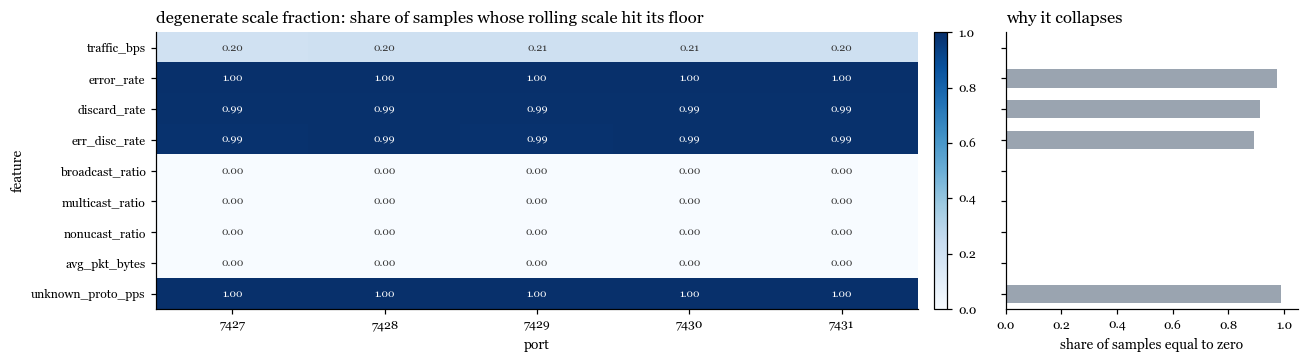

errors_pps > 0.05 的樣本數 20 / 43,200；其中落在事件時窗內的比例 1.000
非零但低於閾值的背景值 [0.0033, 0.0067, 0.01]


In [23]:
def degenerate_fraction(scale, values):
    """Share of samples where the scale collapsed onto the floor (a near-constant metric)."""
    floor = scale_floor(values)
    return float((np.asarray(scale, dtype=float) <= floor * 1.0001).mean())

DEGEN_COLS = ["traffic_bps", "error_rate", "discard_rate", "err_disc_rate",
              "broadcast_ratio", "multicast_ratio", "nonucast_ratio",
              "avg_pkt_bytes", "unknown_proto_pps"]

per_port = {}
for port_id, group in telemetry.groupby("port_id", observed=True):
    g = group.sort_values("timestamp").reset_index(drop=True)
    per_port[port_id] = {
        col: degenerate_fraction(
            rolling_robust(g[col], WINDOW)[1], g[col])
        for col in DEGEN_COLS
    }

degen = pd.DataFrame(per_port)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4),
                         gridspec_kw={"width_ratios": [3, 1.1]}, sharey=True)

im = axes[0].imshow(degen.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[0].set_xticks(range(degen.shape[1]))
axes[0].set_xticklabels([c[-4:] for c in degen.columns], fontsize=8)
axes[0].set_yticks(range(len(degen))); axes[0].set_yticklabels(degen.index, fontsize=8)
axes[0].set_xlabel("port")
axes[0].set_ylabel("feature")
for r in range(degen.shape[0]):
    for c in range(degen.shape[1]):
        v = degen.iat[r, c]
        axes[0].text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=7,
                     color="white" if v > 0.55 else "#333333")
axes[0].grid(False)
axes[0].set_title("degenerate scale fraction: share of samples whose rolling scale hit its floor")
fig.colorbar(im, ax=axes[0], fraction=0.025, pad=0.02)

zshare = [(telemetry[c] == 0).mean() for c in DEGEN_COLS]
axes[1].barh(range(len(DEGEN_COLS)), zshare, color=PALETTE["muted"], height=0.6)
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel("share of samples equal to zero")
axes[1].set_title("why it collapses")
axes[1].grid(False)
fig.tight_layout()
plt.show()

over = telemetry["errors_pps"] > 0.05
print(f"errors_pps > 0.05 的樣本數 {int(over.sum())} / {len(telemetry):,}；"
      f"其中落在事件時窗內的比例 {truth_mask(telemetry, events)[over].mean():.3f}")
print(f"非零但低於閾值的背景值 {sorted(set(telemetry.loc[(telemetry['errors_pps'] > 0) & ~over, 'errors_pps'].round(4)))}")

### **Ablation：**

* Parameter：固定閾值 `0.05` 是手動設定的，跟資料裡量到的背景值有關。
* Architecture：判斷一個特徵該用固定閾值還是 Z-score，目前是人工判斷（看 `degenerate_fraction`），沒有自動切換的邏輯。
* Per-port：5 個 port 目前共用同一個 `0.05`；不同 port 的錯誤率背景值不一定相同，值得各自校準。
* Adaptive：閾值可以用每個 port 自己的歷史背景值（例如 P99）自動算出來，而不是寫死一個全域常數。

## 8. 另一個視角：Change Point 偵測（雙移動平均）

第 1 到 5 步都在回答「這一筆讀數離正常有多遠」；但水位本身緩慢位移，從來不會有任何單一讀數看起來夠極端，是這五步都答不了的另一種問題。雙移動平均（Dual MA）跟第 4 節的 Seasonal、Peer 一樣，是主分數之外另外保留的一個視角，不是要取代前面五步：

$$\text{divergence} = \frac{\text{MA}_{\text{short}} - \text{MA}_{\text{long}}}{\vert{}\text{MA}_{\text{long}}\vert{} + \epsilon}$$

* **權衡：** 快均線反應迅速，慢均線追蹤長期趨勢。Dual MA 能捕捉水位階躍，但會引入與短視窗長度成正比的偵測延遲。
* **脈絡抑制：** 若水位位移的時間點符合變更日曆（例如事件 A / CH-02），屬於預期的維運變更，不應觸發告警。

/var/folders/x7/7zwx0z0d7jj_2s9ndx3lg7200000gn/T/ipykernel_54657/1828164281.py:42: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Georgia.
  fig.tight_layout()
/var/folders/x7/7zwx0z0d7jj_2s9ndx3lg7200000gn/T/ipykernel_54657/1828164281.py:42: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) Georgia.
  fig.tight_layout()
/opt/miniconda3/envs/aiops-anomaly-zero-to-hero/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Georgia.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/aiops-anomaly-zero-to-hero/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) Georgia.
  fig.canvas.print_figure(bytes_io, **kw)


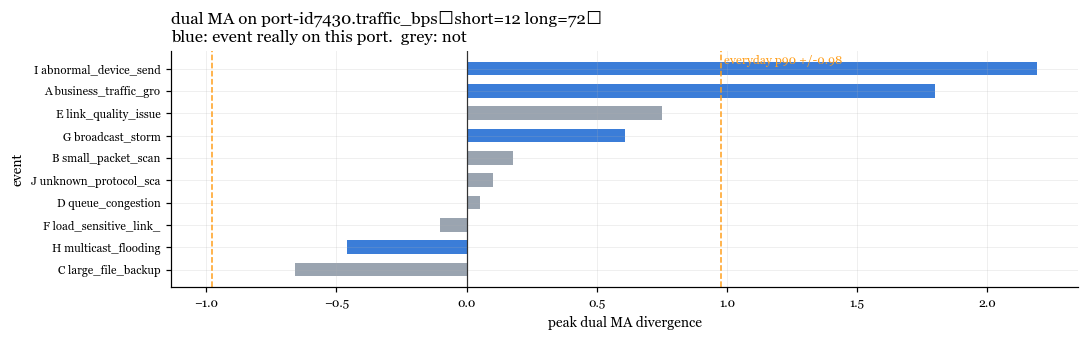

In [24]:
def score_dual_ma(values, short, long):
    """Change-point statistic: relative divergence between a short-window and a
    long-window moving average, not a (value-center)/scale deviation score."""
    fast = values.rolling(short, min_periods=max(2, short // 2)).mean()  # short-window average, tracks the recent level
    slow = values.rolling(long, min_periods=max(2, long // 2)).mean()  # long-window average, tracks the level before that
    return (fast - slow) / (slow.abs() + 1e-9)  # relative divergence between the two levels, epsilon guards division by zero

CP_PORT = "port-id7430"
SHORT, LONG = WINDOW, 6 * WINDOW

cp = telemetry[telemetry["port_id"] == CP_PORT].sort_values("timestamp").reset_index(drop=True)
dma = score_dual_ma(cp["traffic_bps"], short=SHORT, long=LONG)

rows = []
for e in events.drop_duplicates("event_id").itertuples():
    seg = dma[(cp["timestamp"] >= e.start) & (cp["timestamp"] <= e.end)].dropna()
    rows.append({
        "ev": e.event_id,
        "type": e.event_type,
        "hits_this_port": bool(((events["event_id"] == e.event_id)
                                & (events["port_id"] == CP_PORT)).any()),
        "peak_dual_ma": round(float(seg.loc[seg.abs().idxmax()]), 2),
    })

divergence = pd.DataFrame(rows).sort_values("peak_dual_ma")

fig, ax = plt.subplots(figsize=(10, 3.2))
colors = [PALETTE["signal"] if h else PALETTE["muted"] for h in divergence["hits_this_port"]]
ax.barh(range(len(divergence)), divergence["peak_dual_ma"], color=colors, height=0.62)
ax.axvline(0, color="#333333", lw=0.8)
p90 = float(dma.abs().quantile(0.9))
for x in (-p90, p90):
    ax.axvline(x, color=PALETTE["truth"], ls="--", lw=1.0)
ax.text(p90, len(divergence) - 0.4, f" everyday p90 +/-{p90:.2f}", fontsize=8,
        color=PALETTE["truth"], va="top")
ax.set_yticks(range(len(divergence)))
ax.set_yticklabels([f"{r.ev} {r.type[:20]}" for r in divergence.itertuples()], fontsize=7.5)
ax.set_xlabel("peak dual MA divergence")
ax.set_ylabel("event")
ax.set_title(f"dual MA on {CP_PORT}.traffic_bps（short={SHORT} long={LONG}）\n"
             "blue: event really on this port.  grey: not")
fig.tight_layout()
plt.show()

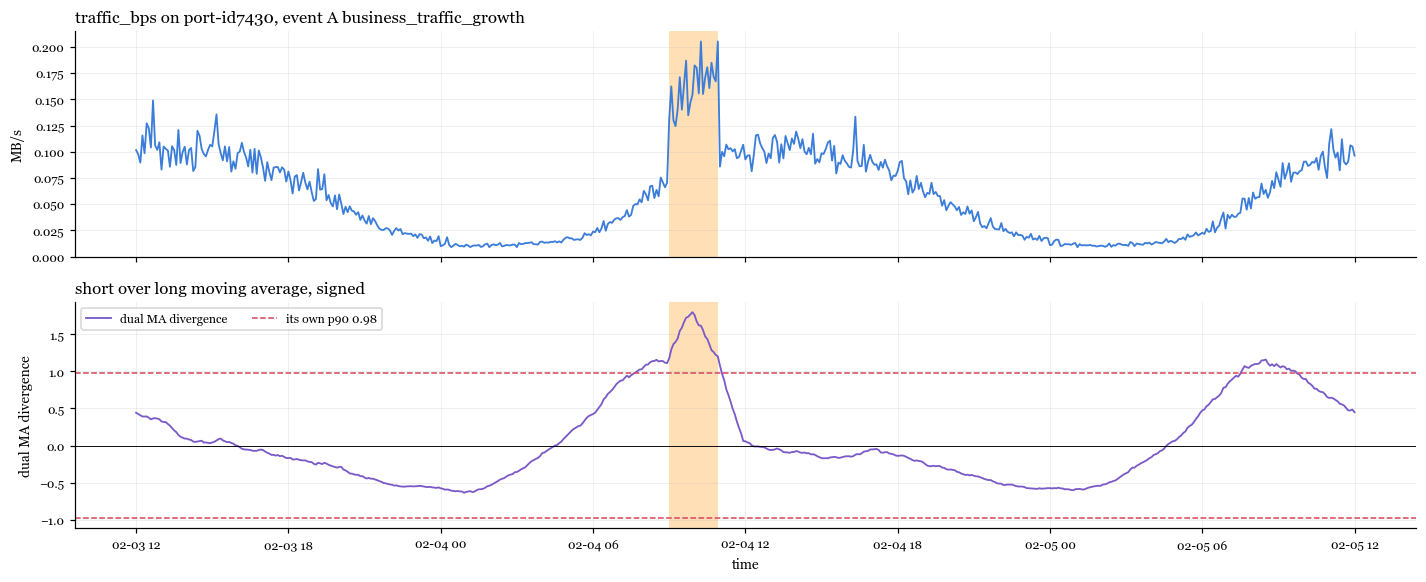

In [25]:
cp = cp.copy()
cp["dual_ma"] = dma
cp["is_incident"] = truth_mask(cp, events)
cwin = cp[(cp["timestamp"] >= "2026-02-03 12:00")
          & (cp["timestamp"] <= "2026-02-05 12:00")].reset_index(drop=True)
p90 = float(dma.abs().quantile(0.90))

fig, axes = plt.subplots(2, 1, figsize=(13, 5.4), sharex=True)

axes[0].plot(cwin["timestamp"], cwin["traffic_bps"] / 1e6, color="#3B7DD8", lw=1.2)
axes[0].set_title(f"traffic_bps on {CP_PORT}, event A business_traffic_growth",
                  loc="left", fontsize=11)
axes[0].set_ylabel("MB/s", fontsize=9)

axes[1].plot(cwin["timestamp"], cwin["dual_ma"], color="#7A5AC7", lw=1.2,
             label="dual MA divergence")
axes[1].axhline(p90, color="#D6455D", ls="--", lw=1.0, label=f"its own p90 {p90:.2f}")
axes[1].axhline(-p90, color="#D6455D", ls="--", lw=1.0)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_title("short over long moving average, signed", loc="left", fontsize=11)
axes[1].set_xlabel("time")
axes[1].set_ylabel("dual MA divergence")
axes[1].legend(fontsize=8, loc="upper left", ncol=3)

for ax in axes:
    shade_truth(ax, cwin["timestamp"], cwin["is_incident"])
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

### **Ablation：**

* Parameter：`SHORT`／`LONG`（快、慢視窗長度）與隱含的 p90 閾值。
* Architecture：雙移動平均只是眾多 change point 方法之一（Lab 02 §1b 的 CUSUM 是另一種）。
* Per-port：目前只示範 `CP_PORT` 一個 port；`SHORT`／`LONG` 沒有理由所有 port 共用同一組。


## 9. 回顧：五步各自關掉了哪一種盲點

把前面五步對到這張表，會看到同一件事分兩次發生：Point Anomaly（事件 D）第 1、2 步就處理掉了，靠的是換 Baseline；Contextual（事件 B）跟 Collective（事件 G／H）靠的完全是第 3 步的特徵組合，不管 Baseline 多聰明都碰不到，因為問題出在被量的量本身，不是量它的方法。Change Point（事件 A）是另一個視角（第 8 節），量的是水位本身有沒有位移，跟前面五步問的不是同一個問題。

| 異常類別 | 定義與特徵 | 資料集範例 | 實際解法 |
| --- | --- | --- | --- |
| **Point Anomaly** | 單一讀數顯著偏離區域脈絡。 | 事件 D (`queue_congestion`) | 第 1、2 步：Rolling Robust Z-score |
| **Contextual Anomaly** | 數值在全域看正常，但在特定脈絡下異常。 | 事件 B (`small_packet_scan`) | 第 3 步：切換特徵 (`avg_pkt_bytes`) |
| **Collective Anomaly** | 單點看皆正常，但整體序列組合異常。 | 事件 G & H (Broadcast/Multicast Storm) | 第 3 步：多特徵組合，而非更聰明的 Baseline |
| **Change Point** | 均值水位在特定時間點產生持續性階躍。 | 事件 A / CH-02 | 第 8 節，另一個視角：雙移動平均（Dual MA） |

半張表（Contextual 與 Collective）是特徵選對了才看得見，跟 Baseline 選得多細無關；只練 Baseline、從不重新檢視餵給它的特徵，會對這一半的異常型態長期視而不見。

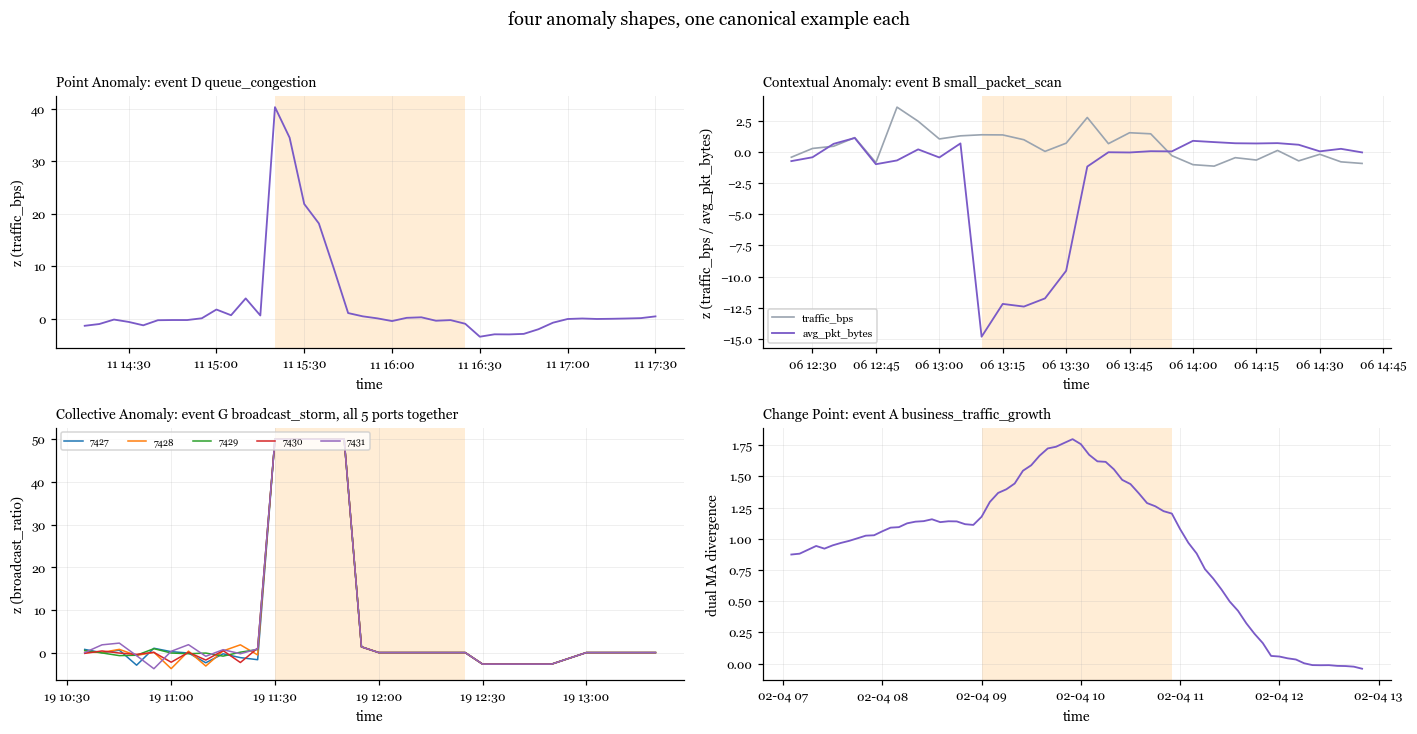

In [26]:
# One canonical example per anomaly shape (Part D+E+F+G recap). Point and
# Contextual/Collective look the same to a human eye until you check which
# feature the z-score is computed on; Change Point is a different question
# entirely (has the level shifted, not how far is this sample from the level).
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))

e = events[events["event_id"] == "D"].iloc[0]
pad = e.end - e.start
view = scored[(scored["port_id"] == e.port_id)
              & (scored["timestamp"] >= e.start - pad)
              & (scored["timestamp"] <= e.end + pad)]
axes[0, 0].plot(view["timestamp"], view["z_traffic_bps"], color=PALETTE["score"], lw=1.2)
axes[0, 0].axvspan(e.start, e.end, color=PALETTE["truth"], alpha=0.18, lw=0)
axes[0, 0].set_title("Point Anomaly: event D queue_congestion", loc="left", fontsize=9)
axes[0, 0].set_xlabel("time")
axes[0, 0].set_ylabel("z (traffic_bps)")

e = events[events["event_id"] == "B"].iloc[0]
pad = e.end - e.start
view = scored[(scored["port_id"] == e.port_id)
              & (scored["timestamp"] >= e.start - pad)
              & (scored["timestamp"] <= e.end + pad)]
axes[0, 1].plot(view["timestamp"], view["z_traffic_bps"], color=PALETTE["muted"], lw=1.1, label="traffic_bps")
axes[0, 1].plot(view["timestamp"], view["z_avg_pkt_bytes"], color=PALETTE["score"], lw=1.2, label="avg_pkt_bytes")
axes[0, 1].axvspan(e.start, e.end, color=PALETTE["truth"], alpha=0.18, lw=0)
axes[0, 1].legend(fontsize=7, loc="lower left")
axes[0, 1].set_xlabel("time")
axes[0, 1].set_ylabel("z (traffic_bps / avg_pkt_bytes)")
axes[0, 1].set_title("Contextual Anomaly: event B small_packet_scan", loc="left", fontsize=9)

g_rows = events[events["event_id"] == "G"]
g_start, g_end = g_rows["start"].min(), g_rows["end"].max()
pad = g_end - g_start
for pid in sorted(scored["port_id"].unique()):
    view = scored[(scored["port_id"] == pid)
                  & (scored["timestamp"] >= g_start - pad)
                  & (scored["timestamp"] <= g_end + pad)]
    axes[1, 0].plot(view["timestamp"], view["z_broadcast_ratio"], lw=1.0, label=pid[-4:])
axes[1, 0].axvspan(g_start, g_end, color=PALETTE["truth"], alpha=0.18, lw=0)
axes[1, 0].legend(fontsize=6, ncol=5, loc="upper left")
axes[1, 0].set_title("Collective Anomaly: event G broadcast_storm, all 5 ports together", loc="left", fontsize=9)
axes[1, 0].set_xlabel("time")
axes[1, 0].set_ylabel("z (broadcast_ratio)")

e = events[events["event_id"] == "A"].iloc[0]
pad = e.end - e.start
view = cp[(cp["timestamp"] >= e.start - pad) & (cp["timestamp"] <= e.end + pad)]
axes[1, 1].plot(view["timestamp"], view["dual_ma"], color=PALETTE["score"], lw=1.2)
axes[1, 1].axvspan(e.start, e.end, color=PALETTE["truth"], alpha=0.18, lw=0)
axes[1, 1].set_title("Change Point: event A business_traffic_growth", loc="left", fontsize=9)
axes[1, 1].set_xlabel("time")
axes[1, 1].set_ylabel("dual MA divergence")

for ax in axes.flat:
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.suptitle("four anomaly shapes, one canonical example each", y=1.02)
fig.tight_layout()
plt.show()

## 10. 架構實作：PromQL vs. 自訂偵測器

基礎的時間序列統計可直接寫成 PromQL：

```promql
# 即時速率計算
rate(node_network_receive_bytes_total{device="en0"}[1m])

# 30 分鐘 Rolling Mean (透過 Subquery)
avg_over_time(rate(node_network_receive_bytes_total{device="en0"}[1m])[30m:])

# 30 分鐘 Rolling Standard Deviation (透過 Subquery)
stddev_over_time(rate(node_network_receive_bytes_total{device="en0"}[1m])[30m:])
```

### 原生 PromQL 的架構限制

1. **缺乏 Robust 聚合函式：** PromQL 沒有原生的 Rolling MAD (`mad_over_time`)；雖然有 `quantile_over_time(0.5, ...)` 可算中位數，但無法直接寫出兩層巢狀中位數。
2. **複雜 Seasonal 與 Peer 邏輯：** 跨工作日/時段的 Seasonal 分組，或是跨動態標籤（Tag）排除自身的 Peer 比較，難以在原生 PromQL 中維護。

**分工界線：** 單一 Vector 的時間聚合適合放在 Prometheus Recording Rules；跨序列比較、跨時間保留狀態與 Non-parametric Baseline，應放在外部 Python 服務（`detector.py`）處理。

## 11. 結尾：完成配對對照表，交給 Lab 02

請完成故障與特徵的配對矩陣（`my_feature_to_fault.csv`）。Lab 02 一開始會把這份檔案讀回來，跟後面章節實際採用的特徵與方法對照。這裡手上握著的分數（`score_max`）跟兩個結構性缺口（Contextual／Collective 靠特徵、事件 E 靠固定閾值），會直接餵進 Lab 02 的下三步：從分數到決策、從決策到能被人採取行動的通知、以及在抓漏率與告警量之間自己選一個立足點。

> **收尾：** 這個 Notebook 沒有啟動任何外部服務。如果 Lab 00 的 `detector.py`、Prometheus、Grafana 或 `node_exporter` 還在背景執行，下面兩格可以檢查、關閉，Lab 01 到 Lab 02 全程都用不到它們。

In [27]:
catalog = pd.read_csv(COURSE_ROOT / "data" / "synthetic" / "synthetic_event_catalog.csv")

worksheet = catalog[["event_id", "event_type", "port_id"]].copy()
worksheet["feature"] = ""
worksheet["baseline"] = ""
worksheet["why"] = ""

print(worksheet.to_string(index=False))

# 匯出特徵配對表，供 Lab 02 評估使用
worksheet.to_csv("my_feature_to_fault.csv", index=False)

event_id                event_type     port_id feature baseline why
       A   business_traffic_growth port-id7430                     
       B         small_packet_scan port-id7428                     
       C         large_file_backup port-id7431                     
       D          queue_congestion port-id7427                     
       E        link_quality_issue port-id7429                     
       F load_sensitive_link_issue port-id7427                     
       G           broadcast_storm       MULTI                     
       H        multicast_flooding       MULTI                     
       I    abnormal_device_sender port-id7430                     
       J     unknown_protocol_scan port-id7428                     


In [28]:
import time
import subprocess, sys

STOP_SERVICES = False  # flip to True and re-run this cell when you are actually done

DETECTOR_PORT = 9200  # detector.py's default port, Lab 00 §5
STOP_TARGETS = [
    ("Prometheus", 9090),
    ("node_exporter" if sys.platform != "win32" else "windows_exporter", 9100 if sys.platform != "win32" else 9182),
    ("Grafana", 3000),
    ("detector.py", DETECTOR_PORT),
]

def _pids_on_port(port):
    """Best-effort, cross-platform: PIDs of whatever is listening on `port`."""
    try:
        if sys.platform == "win32":
            out = subprocess.run(["netstat", "-ano"], capture_output=True, text=True).stdout
            return sorted({ln.split()[-1] for ln in out.splitlines()
                          if f":{port} " in ln and "LISTENING" in ln})
        out = subprocess.run(["lsof", "-ti", f":{port}"], capture_output=True, text=True).stdout
        return sorted({p for p in out.split() if p})
    except FileNotFoundError:
        return []

if not STOP_SERVICES:
    print("STOP_SERVICES is False, nothing done. Set it to True above and re-run this cell to actually stop them.")
else:
    def _kill(pid):
        if sys.platform == "win32":
            subprocess.run(["taskkill", "/F", "/PID", pid], capture_output=True)
        else:
            subprocess.run(["kill", pid], capture_output=True)

    for name, port in STOP_TARGETS:
        for pid in _pids_on_port(port):
            print(f"stopping {name} on :{port}  pid {pid}")
            _kill(pid)

    time.sleep(1)
    for name, port in STOP_TARGETS:
        state = "still up" if _pids_on_port(port) else "stopped"
        print(f"  {state:<10} {name:<16} :{port}")

found = False
for name, port in STOP_TARGETS:
    pids = _pids_on_port(port)
    if pids:
        found = True
        print(f"  {name:<16} :{port:<6} pid(s) {', '.join(pids)}")
if not found:
    print("  nothing on these ports right now, already clean")


STOP_SERVICES is False, nothing done. Set it to True above and re-run this cell to actually stop them.
  Grafana          :3000   pid(s) 58922
